In [1]:
import pandas as pd

CSV_PATH = "/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/curated/dataset_curated.csv"

df = pd.read_csv(CSV_PATH)

print("=== FORMA DEL CSV ===")
print(f"Filas: {len(df):,} | Columnas: {list(df.columns)}")

print("\n=== PRIMERAS 3 FILAS ===")
print(df.head(3).to_string())

print("\n=== VALORES ÚNICOS POR COLUMNA ===")
for col in ["split", "weather", "timeofday", "clahe_mode"]:
    print(f"\n  [{col}]")
    print(f"  {df[col].value_counts().to_dict()}")

print("\n=== NULOS POR COLUMNA ===")
print(df.isnull().sum())

print("\n=== EJEMPLO DE path_curada ===")
print(df["path_curada"].iloc[0])

=== FORMA DEL CSV ===
Filas: 61,345 | Columnas: ['image', 'num_objects', 'weather', 'timeofday', 'split', 'path_curada', 'clahe_mode']

=== PRIMERAS 3 FILAS ===
                   image  num_objects weather  timeofday  split                                                                                                        path_curada clahe_mode
0  0000f77c-6257be58.jpg            2   clear    daytime  train  /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/curated/train/0000f77c-6257be58_curated.jpg     normal
1  0000f77c-cb820c98.jpg            7   clear  dawn/dusk  train  /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/curated/train/0000f77c-cb820c98_curated.jpg     normal
2  0001542f-5ce3cf52.jpg           10   clear      night    val    /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/curated/val/0001542f-5ce3cf52_curated.jpg      night

=== VALORES ÚNICOS POR COLUMNA ===

  [split]
  {'train': 42941, 'val': 9202, 

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

warnings.filterwarnings('ignore')

BASE = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks")
DATA = BASE / "data/curated"
CSV_PATH = DATA / "dataset_curated.csv"

OUT_BASE  = BASE / "data/spatial_outputs"
OUT_BOXES = OUT_BASE / "boxes"
OUT_MASKS = OUT_BASE / "masks"
OUT_FEATS = OUT_BASE / "features"

for d in [OUT_BOXES, OUT_MASKS, OUT_FEATS]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
print(f"Dispositivo: {DEVICE} | AMP: {USE_AMP}")

torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cuda | AMP: True


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

IMG_SIZES = {
    "yolo":      (416, 416),
    "segformer": (512, 512),
    "resnet":    (384, 288),
}


class BDD100KSpatial(Dataset):

    def __init__(self, csv_path: str, split: str, model: str = "yolo"):
        df = pd.read_csv(csv_path)
        self.df    = df[df["split"] == split].reset_index(drop=True)
        self.model = model
        self.size  = IMG_SIZES[model]

        self.transform = T.Compose([
            T.Resize(self.size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path_curada"]).convert("RGB")
        return {
            "image":       self.transform(img),
            "image_id":    row["image"],          # ← corregido: era "filename"
            "weather":     row["weather"],
            "timeofday":   row["timeofday"],
            "clahe_mode":  row["clahe_mode"],
            "num_objects": row["num_objects"],    # ← columna extra disponible
            "split":       row["split"],
            "img_path":    row["path_curada"],
        }

    @staticmethod
    def collate_fn(batch):
        return {
            "image":       torch.stack([b["image"] for b in batch]),
            "image_id":    [b["image_id"]    for b in batch],
            "weather":     [b["weather"]     for b in batch],
            "timeofday":   [b["timeofday"]   for b in batch],
            "clahe_mode":  [b["clahe_mode"]  for b in batch],
            "num_objects": [b["num_objects"] for b in batch],
            "img_path":    [b["img_path"]    for b in batch],
        }

In [4]:
BATCH_SIZE  = 8
NUM_WORKERS = 4
ACCUM_STEPS = 4

def make_loaders(csv_path: str, model: str) -> dict:
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = BDD100KSpatial(csv_path=csv_path, split=split, model=model)
        loaders[split] = DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=(split == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=True,
            persistent_workers=True,
            drop_last=True,
            collate_fn=BDD100KSpatial.collate_fn,
        )
    return loaders

loaders_yolo      = make_loaders(CSV_PATH, model="yolo")
loaders_segformer = make_loaders(CSV_PATH, model="segformer")
loaders_resnet    = make_loaders(CSV_PATH, model="resnet")

print("Loaders listos:")
for nombre, ldr in [("yolo", loaders_yolo), ("segformer", loaders_segformer), ("resnet", loaders_resnet)]:
    n = len(ldr["train"].dataset)
    print(f"  {nombre:10s} → train={n:,} muestras | tamaño={IMG_SIZES[nombre]}")

Loaders listos:
  yolo       → train=42,941 muestras | tamaño=(416, 416)
  segformer  → train=42,941 muestras | tamaño=(512, 512)
  resnet     → train=42,941 muestras | tamaño=(384, 288)


In [5]:
def verificar_loader(loaders: dict, model: str):
    batch = next(iter(loaders["train"]))
    imgs  = batch["image"]
    ids   = batch["image_id"]

    C, H, W = 3, *IMG_SIZES[model]
    assert imgs.shape == (BATCH_SIZE, C, H, W), f"Forma incorrecta: {imgs.shape}"
    assert imgs.dtype == torch.float32, "Se esperaba float32"

    print(f"\n[{model}]")
    print(f"  forma del tensor : {tuple(imgs.shape)}  dtype={imgs.dtype}")
    print(f"  rango de píxeles : [{imgs.min():.3f}, {imgs.max():.3f}]")
    print(f"  image_ids        : {ids[:2]} ...")
    print(f"  weather          : {set(batch['weather'])}")
    print(f"  timeofday        : {set(batch['timeofday'])}")
    print(f"  clahe_mode       : {set(batch['clahe_mode'])}")
    print(f"  num_objects      : min={min(batch['num_objects'])} max={max(batch['num_objects'])}")

    n_tr = len(loaders["train"].dataset)
    n_v  = len(loaders["val"].dataset)
    n_te = len(loaders["test"].dataset)
    tot  = n_tr + n_v + n_te
    print(f"  splits           : train={n_tr:,} ({n_tr/tot:.0%}) | val={n_v:,} ({n_v/tot:.0%}) | test={n_te:,} ({n_te/tot:.0%})")

verificar_loader(loaders_yolo,      "yolo")
verificar_loader(loaders_segformer, "segformer")
verificar_loader(loaders_resnet,    "resnet")


[yolo]
  forma del tensor : (8, 3, 416, 416)  dtype=torch.float32
  rango de píxeles : [-2.118, 2.640]
  image_ids        : ['29b61311-fc99c542.jpg', '50d0fd05-8db58ebd.jpg'] ...
  weather          : {'clear', 'partly cloudy', 'undefined', 'overcast', 'snowy', 'rainy'}
  timeofday        : {'night', 'daytime'}
  clahe_mode       : {'night', 'normal', 'shadow'}
  num_objects      : min=4 max=17
  splits           : train=42,941 (70%) | val=9,202 (15%) | test=9,202 (15%)

[segformer]
  forma del tensor : (8, 3, 512, 512)  dtype=torch.float32
  rango de píxeles : [-2.118, 2.640]
  image_ids        : ['040c92cf-a442c0e9.jpg', '71325b00-3d341526.jpg'] ...
  weather          : {'overcast', 'snowy', 'clear'}
  timeofday        : {'dawn/dusk', 'night', 'daytime'}
  clahe_mode       : {'normal', 'night'}
  num_objects      : min=3 max=16
  splits           : train=42,941 (70%) | val=9,202 (15%) | test=9,202 (15%)

[resnet]
  forma del tensor : (8, 3, 384, 288)  dtype=torch.float32
  rango de p

In [6]:
import sys
!{sys.executable} -m pip install ultralytics -q

In [7]:
import importlib
import ultralytics
importlib.reload(ultralytics)

<module 'ultralytics' from '/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/env_ml/lib/python3.10/site-packages/ultralytics/__init__.py'>

In [8]:
!{sys.executable} -m pip install transformers -q

In [9]:
# ── YOLOv8n — detección de objetos ────────────────────────────────
# Clases BDD100K relevantes para predicción de accidentes
YOLO_CLASSES = {
    0: "person",
    1: "rider",
    2: "car",
    3: "truck",
    4: "bus",
    5: "motorcycle",
    6: "bicycle",
    7: "traffic light",
    8: "traffic sign",
}

from ultralytics import YOLO

def cargar_yolo():
    model = YOLO("yolov8n.pt")   # descarga automática si no existe
    model.to(DEVICE)
    print(f"YOLOv8n cargado → {sum(p.numel() for p in model.model.parameters()):,} parámetros")
    return model

yolo_model = cargar_yolo()

YOLOv8n cargado → 3,157,200 parámetros


In [10]:
from huggingface_hub import login
login(token="hf_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")  # pega tu token aquí

In [11]:
print(torch.__version__)

2.5.1+cu121


In [12]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

SEGFORMER_CHECKPOINT = "nvidia/segformer-b0-finetuned-cityscapes-640-1280"

def cargar_segformer():
    processor = SegformerImageProcessor.from_pretrained(
        SEGFORMER_CHECKPOINT,
        token=False
    )
    model = SegformerForSemanticSegmentation.from_pretrained(
        SEGFORMER_CHECKPOINT,
        num_labels=19,
        ignore_mismatched_sizes=True,
        token=False,
        use_safetensors=True
    )
    model.to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"SegFormer-B0 cargado → {n_params:,} parámetros totales | {n_train:,} entrenables")
    return model, processor

segformer_model, segformer_processor = cargar_segformer()

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████| 208/208 [00:00<00:00, 2990.68it/s]

SegFormer-B0 cargado → 3,719,027 parámetros totales | 3,719,027 entrenables


In [13]:
import torchvision.models as models
import torch.nn.functional as F
import torch.nn as nn

class SPPBlock(nn.Module):
    def __init__(self, pool_sizes=[1, 2, 4]):
        super().__init__()
        self.pool_sizes = pool_sizes

    def forward(self, x):
        B, C, H, W = x.shape
        pooled = [x]
        for size in self.pool_sizes:
            p = F.adaptive_avg_pool2d(x, output_size=size)
            p = F.interpolate(p, size=(H, W), mode="bilinear", align_corners=False)
            pooled.append(p)
        return torch.cat(pooled, dim=1)  # (B, C * 4, H, W)


class ResNet18SPP(nn.Module):
    def __init__(self, pool_sizes=[1, 2, 4]):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1,
                                    backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1   # congelado
        self.layer2 = backbone.layer2   # congelado
        self.layer3 = backbone.layer3   # fine-tune
        self.layer4 = backbone.layer4   # fine-tune

        for layer in [self.stem, self.layer1, self.layer2]:
            for p in layer.parameters():
                p.requires_grad = False

        self.spp = SPPBlock(pool_sizes=pool_sizes)
        self.out_channels = 512 * (1 + len(pool_sizes))  # 2048

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.spp(x)
        return x  # (B, 2048, H/32, W/32)


def cargar_resnet_spp():
    model = ResNet18SPP(pool_sizes=[1, 2, 4])
    model.to(DEVICE)
    n_total  = sum(p.numel() for p in model.parameters())
    n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_frozen = n_total - n_train
    print(f"ResNet-18+SPP cargado")
    print(f"  total      : {n_total:,} parámetros")
    print(f"  entrenables: {n_train:,}  |  congelados: {n_frozen:,}")
    print(f"  canales de salida SPP: {model.out_channels}")
    return model

resnet_model = cargar_resnet_spp()

ResNet-18+SPP cargado
  total      : 11,176,512 parámetros
  entrenables: 10,493,440  |  congelados: 683,072
  canales de salida SPP: 2048


In [14]:
def memoria_gpu():
    if not torch.cuda.is_available():
        print("Sin GPU")
        return
    alloc     = torch.cuda.memory_allocated(DEVICE) / 1024**3
    reservada = torch.cuda.memory_reserved(DEVICE)  / 1024**3
    total     = torch.cuda.get_device_properties(DEVICE).total_memory / 1024**3
    print(f"  VRAM usada : {alloc:.2f} GB / {total:.1f} GB  (reservada: {reservada:.2f} GB)")


def offload_modelo(model):
    model.cpu()
    torch.cuda.empty_cache()


print("=== VRAM con los tres modelos en CPU ===")
offload_modelo(yolo_model.model)
offload_modelo(segformer_model)
offload_modelo(resnet_model)
memoria_gpu()

print("\n=== VRAM al cargar solo YOLO en GPU ===")
yolo_model.model.to(DEVICE)
memoria_gpu()

print("\n=== VRAM al cargar solo SegFormer en GPU ===")
offload_modelo(yolo_model.model)
segformer_model.to(DEVICE)
memoria_gpu()

print("\n=== VRAM al cargar solo ResNet+SPP en GPU ===")
offload_modelo(segformer_model)
resnet_model.to(DEVICE)
memoria_gpu()

offload_modelo(resnet_model)
torch.cuda.empty_cache()
print("\nTodos los modelos en CPU. Listos para el loop de entrenamiento.")

=== VRAM con los tres modelos en CPU ===
  VRAM usada : 0.00 GB / 5.8 GB  (reservada: 0.00 GB)

=== VRAM al cargar solo YOLO en GPU ===
  VRAM usada : 0.01 GB / 5.8 GB  (reservada: 0.03 GB)

=== VRAM al cargar solo SegFormer en GPU ===
  VRAM usada : 0.01 GB / 5.8 GB  (reservada: 0.03 GB)

=== VRAM al cargar solo ResNet+SPP en GPU ===
  VRAM usada : 0.04 GB / 5.8 GB  (reservada: 0.06 GB)

Todos los modelos en CPU. Listos para el loop de entrenamiento.


In [15]:
from pathlib import Path
from PIL import Image
import numpy as np

SEG_BASE = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_seg/bdd100k/seg")

color_train = SEG_BASE / "color_labels/train"
labels_train = SEG_BASE / "labels/train"

# Conteo de archivos
color_files  = list(color_train.glob("*.png"))
labels_files = list(labels_train.glob("*.png")) if labels_train.exists() else []

print(f"color_labels/train : {len(color_files):,} archivos")
print(f"labels/train       : {len(labels_files):,} archivos")

# Propiedades de la primera máscara de color
if color_files:
    img = Image.open(color_files[0])
    arr = np.array(img)
    print(f"\nEjemplo color_label:")
    print(f"  archivo : {color_files[0].name}")
    print(f"  tamaño  : {img.size}")
    print(f"  modo    : {img.mode}")
    print(f"  shape   : {arr.shape}")

# Propiedades de la primera máscara de labels (valores de clase)
if labels_files:
    img2 = Image.open(labels_files[0])
    arr2 = np.array(img2)
    print(f"\nEjemplo label:")
    print(f"  archivo : {labels_files[0].name}")
    print(f"  tamaño  : {img2.size}")
    print(f"  modo    : {img2.mode}")
    print(f"  shape   : {arr2.shape}")
    print(f"  valores únicos: {np.unique(arr2)}")

color_labels/train : 7,000 archivos
labels/train       : 7,000 archivos

Ejemplo color_label:
  archivo : 2dcbcdb1-c6e60000_train_color.png
  tamaño  : (1280, 720)
  modo    : RGBA
  shape   : (720, 1280, 4)

Ejemplo label:
  archivo : 370c9841-da2c6686_train_id.png
  tamaño  : (1280, 720)
  modo    : L
  shape   : (720, 1280)
  valores únicos: [  0   1   2   5   6   7   8  10  11  13  15 255]


In [16]:
import pandas as pd
from pathlib import Path

SEG_BASE = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_seg/bdd100k/seg")
CSV_PATH = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/curated/dataset_curated.csv")

df = pd.read_csv(CSV_PATH)
df_train = df[df["split"] == "train"]

# Extraer IDs base de las máscaras
mascaras = list((SEG_BASE / "labels/train").glob("*.png"))
mask_ids = {m.stem.replace("_train_id", "") for m in mascaras}

# Extraer IDs base de las imágenes curadas
img_ids = {Path(p).stem.replace("_curated", "") for p in df_train["path_curada"]}

# Cruce
coincidencias = img_ids & mask_ids
solo_imagen   = img_ids - mask_ids
solo_mascara  = mask_ids - img_ids

print(f"Imágenes en train CSV : {len(img_ids):,}")
print(f"Máscaras disponibles  : {len(mask_ids):,}")
print(f"Coincidencias         : {len(coincidencias):,}")
print(f"Imágenes sin máscara  : {len(solo_imagen):,}")
print(f"Máscaras sin imagen   : {len(solo_mascara):,}")

print(f"\nEjemplo ID imagen  : {list(img_ids)[:2]}")
print(f"Ejemplo ID máscara : {list(mask_ids)[:2]}")

Imágenes en train CSV : 42,941
Máscaras disponibles  : 7,000
Coincidencias         : 1,853
Imágenes sin máscara  : 41,088
Máscaras sin imagen   : 5,147

Ejemplo ID imagen  : ['5a1a6da0-94320c0a', '4cd722e9-325db75d']
Ejemplo ID máscara : ['6c234790-6587b729', '198cfa25-f7b54297']


In [17]:
SEG_IMGS = SEG_BASE / "images/train"
imgs_seg = list(SEG_IMGS.glob("*.jpg"))
print(f"Imágenes originales en seg/images/train: {len(imgs_seg):,}")
print(f"Ejemplo: {imgs_seg[0].name}")

Imágenes originales en seg/images/train: 7,000
Ejemplo: 0004a4c0-d4dff0ad.jpg


In [18]:
SEG_IMGS  = SEG_BASE / "images/train"
SEG_MASKS = SEG_BASE / "labels/train"

imgs  = {f.stem: f for f in SEG_IMGS.glob("*.jpg")}
masks = {f.stem.replace("_train_id", ""): f for f in SEG_MASKS.glob("*.png")}

coincidencias = set(imgs.keys()) & set(masks.keys())

print(f"Imágenes seg/images/train : {len(imgs):,}")
print(f"Máscaras seg/labels/train : {len(masks):,}")
print(f"Pares completos           : {len(coincidencias):,}")
print(f"\nEjemplo imagen : {list(imgs.values())[0]}")
print(f"Ejemplo máscara: {list(masks.values())[0]}")

Imágenes seg/images/train : 7,000
Máscaras seg/labels/train : 7,000
Pares completos           : 7,000

Ejemplo imagen : /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_seg/bdd100k/seg/images/train/0004a4c0-d4dff0ad.jpg
Ejemplo máscara: /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_seg/bdd100k/seg/labels/train/370c9841-da2c6686_train_id.png


In [19]:
SEG_BASE  = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_seg/bdd100k/seg")
SEG_IMGS  = SEG_BASE / "images/train"
SEG_MASKS = SEG_BASE / "labels/train"

imgs  = {f.stem: f for f in SEG_IMGS.glob("*.jpg")}
masks = {f.stem.replace("_train_id", ""): f for f in SEG_MASKS.glob("*.png")}

coincidencias = set(imgs.keys()) & set(masks.keys())

print(f"Imágenes en seg/images/train : {len(imgs):,}")
print(f"Máscaras en seg/labels/train : {len(masks):,}")
print(f"Pares completos              : {len(coincidencias):,}")

if imgs:
    print(f"\nEjemplo imagen : {list(imgs.values())[0].name}")
if masks:
    print(f"Ejemplo máscara: {list(masks.values())[0].name}")

Imágenes en seg/images/train : 7,000
Máscaras en seg/labels/train : 7,000
Pares completos              : 7,000

Ejemplo imagen : 0004a4c0-d4dff0ad.jpg
Ejemplo máscara: 370c9841-da2c6686_train_id.png


In [20]:
# ── Dataset específico para SegFormer con pares imagen+máscara ─────

SEG_BASE  = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_seg/bdd100k/seg")
SEG_IMGS  = SEG_BASE / "images/train"
SEG_MASKS = SEG_BASE / "labels/train"

# 255 = void/unlabeled en BDD100K → ignorar en loss
IGNORE_INDEX = 255
NUM_CLASSES  = 19


class BDD100KSegDataset(Dataset):
    """
    Dataset para fine-tuning de SegFormer.
    Usa imágenes originales de BDD100K seg (no curadas) con sus
    máscaras de clase en formato L (un entero por píxel).
    """

    def __init__(self, img_dir: Path, mask_dir: Path, img_size=(512, 512)):
        self.img_size = img_size

        # Construir pares imagen → máscara por ID
        imgs  = {f.stem: f for f in img_dir.glob("*.jpg")}
        masks = {f.stem.replace("_train_id", ""): f for f in mask_dir.glob("*.png")}
        ids   = sorted(set(imgs.keys()) & set(masks.keys()))

        self.pairs = [(imgs[i], masks[i]) for i in ids]
        print(f"  Pares imagen+máscara encontrados: {len(self.pairs):,}")

        # Transformaciones imagen — sin augmentaciones que rompan geometría
        self.img_transform = T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img  = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)   # modo L, valores 0-18 + 255

        img_t  = self.img_transform(img)
        mask_t = T.functional.resize(
            mask,
            self.img_size,
            interpolation=T.InterpolationMode.NEAREST  # nunca interpolar clases
        )
        mask_t = torch.tensor(np.array(mask_t), dtype=torch.long)

        return {
            "image":    img_t,
            "mask":     mask_t,
            "image_id": img_path.stem,
        }

    @staticmethod
    def collate_fn(batch):
        return {
            "image":    torch.stack([b["image"] for b in batch]),
            "mask":     torch.stack([b["mask"]  for b in batch]),
            "image_id": [b["image_id"] for b in batch],
        }


# ── Instanciar dataset y loader ────────────────────────────────────
print("Creando BDD100KSegDataset...")
seg_dataset = BDD100KSegDataset(SEG_IMGS, SEG_MASKS, img_size=(512, 512))

# Split manual 85/15 sobre los 7,000 pares (no hay CSV para este subset)
n_total = len(seg_dataset)
n_val   = int(n_total * 0.15)
n_train = n_total - n_val

seg_train, seg_val = torch.utils.data.random_split(
    seg_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

seg_loader_train = DataLoader(
    seg_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
    collate_fn=BDD100KSegDataset.collate_fn,
)

seg_loader_val = DataLoader(
    seg_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False,
    collate_fn=BDD100KSegDataset.collate_fn,
)

print(f"  Train: {len(seg_train):,} | Val: {len(seg_val):,}")

# Verificación rápida
batch = next(iter(seg_loader_train))
print(f"\nVerificación batch:")
print(f"  imagen : {tuple(batch['image'].shape)}  dtype={batch['image'].dtype}")
print(f"  máscara: {tuple(batch['mask'].shape)}   dtype={batch['mask'].dtype}")
print(f"  clases únicas en batch: {batch['mask'].unique().tolist()}")

Creando BDD100KSegDataset...
  Pares imagen+máscara encontrados: 7,000
  Train: 5,950 | Val: 1,050

Verificación batch:
  imagen : (8, 3, 512, 512)  dtype=torch.float32
  máscara: (8, 512, 512)   dtype=torch.int64
  clases únicas en batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 18, 255]


In [21]:
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast

# ── Loss: CrossEntropy ponderada + Dice ───────────────────────────
def dice_loss(preds, targets, ignore_index=255, smooth=1e-6):
    """
    Dice Loss promediado sobre clases presentes en el batch.
    preds   : (B, C, H, W) logits
    targets : (B, H, W)    enteros de clase
    """
    preds  = F.softmax(preds, dim=1)
    valid  = (targets != ignore_index)
    loss   = 0.0
    count  = 0
    for c in range(preds.shape[1]):
        pred_c   = preds[:, c][valid]
        target_c = (targets[valid] == c).float()
        inter    = (pred_c * target_c).sum()
        union    = pred_c.sum() + target_c.sum()
        loss    += 1 - (2 * inter + smooth) / (union + smooth)
        count   += 1
    return loss / max(count, 1)


def combined_loss(logits, masks, ignore_index=255):
    """50% CrossEntropy + 50% Dice."""
    ce   = F.cross_entropy(logits, masks, ignore_index=ignore_index)
    dice = dice_loss(logits, masks, ignore_index=ignore_index)
    return 0.5 * ce + 0.5 * dice


def compute_miou(preds, targets, num_classes=19, ignore_index=255):
    """
    Calcula mIoU global y por clase.
    preds   : (B, H, W) clases predichas
    targets : (B, H, W) clases reales
    """
    ious = []
    for c in range(num_classes):
        pred_c   = (preds == c)
        target_c = (targets == c)
        valid    = (targets != ignore_index)
        inter    = (pred_c & target_c & valid).sum().item()
        union    = ((pred_c | target_c) & valid).sum().item()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else 0.0


print("Funciones de loss y métricas definidas ✅")

Funciones de loss y métricas definidas ✅


In [24]:
seg_loader_train = DataLoader(
    seg_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
    collate_fn=BDD100KSegDataset.collate_fn,
)

In [25]:
seg_loader_val = DataLoader(
    seg_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False,
    collate_fn=BDD100KSegDataset.collate_fn,
)

In [26]:
print("Loaders recreados ✅")

Loaders recreados ✅


In [28]:
# ── Liberar memoria primero ────────────────────────────────────────
torch.cuda.empty_cache()

# ── Recrear dataset con imagen más pequeña ────────────────────────
seg_dataset_small = BDD100KSegDataset(SEG_IMGS, SEG_MASKS, img_size=(384, 384))

n_total = len(seg_dataset_small)
n_val   = int(n_total * 0.15)
n_train = n_total - n_val

seg_train, seg_val = torch.utils.data.random_split(
    seg_dataset_small,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# ── Recrear loaders con batch_size=4 ──────────────────────────────
seg_loader_train = DataLoader(
    seg_train,
    batch_size=4,           # reducido de 8 a 4
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
    collate_fn=BDD100KSegDataset.collate_fn,
)

seg_loader_val = DataLoader(
    seg_val,
    batch_size=4,           # reducido de 8 a 4
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False,
    collate_fn=BDD100KSegDataset.collate_fn,
)

# ── Verificar memoria con un batch ────────────────────────────────
segformer_model.to(DEVICE)
batch_prueba = next(iter(seg_loader_train))
imgs  = batch_prueba["image"].to(DEVICE)
masks = batch_prueba["mask"].to(DEVICE)

with torch.no_grad():
    with autocast(enabled=USE_AMP):
        out = segformer_model(pixel_values=imgs)

mb = torch.cuda.memory_allocated(DEVICE) / 1024**2
print(f"Batch prueba OK ✅")
print(f"  imagen : {tuple(imgs.shape)}")
print(f"  VRAM   : {mb:.0f} MB / 5,800 MB")

del imgs, masks, out, batch_prueba
torch.cuda.empty_cache()
offload_modelo(segformer_model)

  Pares imagen+máscara encontrados: 7,000
Batch prueba OK ✅
  imagen : (4, 3, 384, 384)
  VRAM   : 5192 MB / 5,800 MB


In [29]:
torch.cuda.empty_cache()

# Recrear dataset con 320×320
seg_dataset_small = BDD100KSegDataset(SEG_IMGS, SEG_MASKS, img_size=(320, 320))

n_total = len(seg_dataset_small)
n_val   = int(n_total * 0.15)
n_train = n_total - n_val

seg_train, seg_val = torch.utils.data.random_split(
    seg_dataset_small,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

seg_loader_train = DataLoader(
    seg_train,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
    collate_fn=BDD100KSegDataset.collate_fn,
)

seg_loader_val = DataLoader(
    seg_val,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False,
    collate_fn=BDD100KSegDataset.collate_fn,
)

# Prueba con forward + backward para simular entrenamiento real
segformer_model.to(DEVICE)
optimizer_test = torch.optim.AdamW(segformer_model.parameters(), lr=1e-4)
scaler_test    = GradScaler(enabled=USE_AMP)

batch_prueba = next(iter(seg_loader_train))
imgs  = batch_prueba["image"].to(DEVICE)
masks = batch_prueba["mask"].to(DEVICE)

optimizer_test.zero_grad()
with autocast(enabled=USE_AMP):
    out       = segformer_model(pixel_values=imgs)
    logits_up = F.interpolate(out.logits, size=masks.shape[-2:],
                              mode="bilinear", align_corners=False)
    loss      = combined_loss(logits_up, masks)

scaler_test.scale(loss).backward()

mb = torch.cuda.memory_allocated(DEVICE) / 1024**2
print(f"Forward + backward OK ✅")
print(f"  imagen : {tuple(imgs.shape)}")
print(f"  loss   : {loss.item():.4f}")
print(f"  VRAM   : {mb:.0f} MB / 5,800 MB")

del imgs, masks, out, logits_up, loss, optimizer_test, scaler_test, batch_prueba
torch.cuda.empty_cache()
offload_modelo(segformer_model)

  Pares imagen+máscara encontrados: 7,000
Forward + backward OK ✅
  imagen : (4, 3, 320, 320)
  loss   : 0.5131
  VRAM   : 2585 MB / 5,800 MB


In [30]:
# ── Actualizar BATCH_SIZE antes de entrenar ────────────────────────
BATCH_SIZE = 4
ACCUM_STEPS = 8   # batch efectivo = 4 × 8 = 32 (igual que antes)

torch.cuda.empty_cache()
offload_modelo(segformer_model)

# ── Reconfigurar entrenamiento ────────────────────────────────────
EPOCHS        = 20
LR            = 1e-4
PATIENCE      = 4
CHECKPOINT_PATH    = OUT_BASE / "segformer_best.pt"
CHECKPOINT_DIR_EPO = OUT_BASE / "checkpoints"
CHECKPOINT_DIR_EPO.mkdir(parents=True, exist_ok=True)

segformer_model.to(DEVICE)

optimizer = torch.optim.AdamW(
    segformer_model.parameters(),
    lr=LR,
    weight_decay=1e-2
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(seg_loader_train) // ACCUM_STEPS,
    epochs=EPOCHS,
    pct_start=0.1,
)

scaler = GradScaler(enabled=USE_AMP)

def barra(actual, total, ancho=30):
    pct   = actual / total
    lleno = int(ancho * pct)
    b     = "█" * lleno + "░" * (ancho - lleno)
    return f"[{b}] {actual}/{total} ({pct*100:.0f}%)"

def memoria_actual():
    if not torch.cuda.is_available():
        return "CPU"
    mb = torch.cuda.memory_allocated(DEVICE) / 1024**2
    return f"{mb:.0f}MB"

historial     = {"epoch": [], "train_loss": [], "val_loss": [], "val_miou": []}
best_miou     = 0.0
epochs_no_imp = 0
total_steps   = len(seg_loader_train)

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║         Entrenamiento SegFormer-B0 — BDD100K         ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  Épocas máx  : {EPOCHS:<5}  Patience : {PATIENCE:<5}              ║")
print(f"║  LR          : {LR:<7}  Accum    : {ACCUM_STEPS:<5}              ║")
print(f"║  Batch efect : {BATCH_SIZE*ACCUM_STEPS:<5}  Device  : {str(DEVICE):<6}             ║")
print(f"║  img_size    : 320×320  VRAM libre: ~3.2 GB          ║")
print(f"╚══════════════════════════════════════════════════════╝\n")

for epoch in range(EPOCHS):
    t_epoch = time.time()
    print(f"┌─ Época {epoch+1:02d}/{EPOCHS} {'─'*43}")

    segformer_model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(seg_loader_train):
        imgs  = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE,  non_blocking=True)

        with autocast(enabled=USE_AMP):
            outputs   = segformer_model(pixel_values=imgs)
            logits_up = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )
            loss = combined_loss(logits_up, masks) / ACCUM_STEPS

        scaler.scale(loss).backward()
        train_loss += loss.item() * ACCUM_STEPS

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(segformer_model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 20 == 0 or (step + 1) == total_steps:
            loss_avg  = train_loss / (step + 1)
            lr_actual = optimizer.param_groups[0]["lr"]
            print(f"│  train {barra(step+1, total_steps)} "
                  f"loss={loss_avg:.4f}  lr={lr_actual:.2e}  VRAM={memoria_actual()}",
                  end="\r")

    train_loss /= len(seg_loader_train)
    print(f"│  train {barra(total_steps, total_steps)} "
          f"loss={train_loss:.4f}{'':30}")

    segformer_model.eval()
    val_loss       = 0.0
    val_preds      = []
    val_masks_list = []
    n_val_steps    = len(seg_loader_val)

    with torch.no_grad():
        for vstep, batch in enumerate(seg_loader_val):
            imgs  = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE,  non_blocking=True)

            with autocast(enabled=USE_AMP):
                outputs   = segformer_model(pixel_values=imgs)
                logits_up = F.interpolate(
                    outputs.logits,
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )
                loss = combined_loss(logits_up, masks)

            val_loss += loss.item()
            val_preds.append(logits_up.argmax(dim=1).cpu())
            val_masks_list.append(masks.cpu())

            if (vstep + 1) % 5 == 0 or (vstep + 1) == n_val_steps:
                print(f"│  val   {barra(vstep+1, n_val_steps)}",
                      end="\r")

    val_loss    /= len(seg_loader_val)
    val_preds_t  = torch.cat(val_preds)
    val_masks_t  = torch.cat(val_masks_list)
    val_miou     = compute_miou(val_preds_t, val_masks_t)
    t_total      = time.time() - t_epoch

    print(f"│  val   {barra(n_val_steps, n_val_steps)}{'':30}")
    print(f"│")
    print(f"│  ⏱  {t_total:.0f}s  │  train_loss={train_loss:.4f}  │  "
          f"val_loss={val_loss:.4f}  │  val_mIoU={val_miou:.4f}")

    epo_path = CHECKPOINT_DIR_EPO / f"segformer_epoch_{epoch+1:02d}.pt"
    torch.save({
        "epoch":      epoch + 1,
        "state_dict": segformer_model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "best_miou":  best_miou,
        "val_miou":   val_miou,
        "val_loss":   val_loss,
        "train_loss": train_loss,
    }, epo_path)

    historial["epoch"].append(epoch + 1)
    historial["train_loss"].append(round(train_loss, 4))
    historial["val_loss"].append(round(val_loss, 4))
    historial["val_miou"].append(round(val_miou, 4))

    if val_miou > best_miou:
        best_miou     = val_miou
        epochs_no_imp = 0
        torch.save(segformer_model.state_dict(), CHECKPOINT_PATH)
        print(f"│  ✅ Mejor modelo guardado → mIoU={best_miou:.4f}")
    else:
        epochs_no_imp += 1
        print(f"│  ⚠️  Sin mejora {epochs_no_imp}/{PATIENCE}")
        if epochs_no_imp >= PATIENCE:
            print(f"└─ Early stopping en época {epoch+1}\n")
            break

    print(f"└{'─'*52}\n")

segformer_model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location=DEVICE)
)
offload_modelo(segformer_model)
torch.cuda.empty_cache()

print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║               Resumen del entrenamiento              ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  {'Época':<6} {'train_loss':<12} {'val_loss':<12} {'val_mIoU':<10}  ║")
print(f"╠══════════════════════════════════════════════════════╣")
for i in range(len(historial["epoch"])):
    mejor = " ◀" if historial["val_miou"][i] == best_miou else ""
    print(f"║  {historial['epoch'][i]:<6} {historial['train_loss'][i]:<12} "
          f"{historial['val_loss'][i]:<12} {historial['val_miou'][i]:<10}{mejor:>2}  ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  Mejor val mIoU : {best_miou:.4f}{'':32}║")
print(f"╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║         Entrenamiento SegFormer-B0 — BDD100K         ║
╠══════════════════════════════════════════════════════╣
║  Épocas máx  : 20     Patience : 4                  ║
║  LR          : 0.0001   Accum    : 8                  ║
║  Batch efect : 32     Device  : cuda               ║
║  img_size    : 320×320  VRAM libre: ~3.2 GB          ║
╚══════════════════════════════════════════════════════╝

┌─ Época 01/20 ───────────────────────────────────────────
│  train [██████████████████████████████] 1487/1487 (100%) loss=0.6967                              
│  val   [██████████████████████████████] 263/263 (100%)                              
│
│  ⏱  406s  │  train_loss=0.6967  │  val_loss=nan  │  val_mIoU=0.0138
│  ✅ Mejor modelo guardado → mIoU=0.0138
└────────────────────────────────────────────────────

┌─ Época 02/20 ───────────────────────────────────────────
│  train [██████████████████████████████] 1487/1487 (100%) loss=0.5904 

In [31]:
# ── Diagnóstico de val_loss nan y mIoU estancado ──────────────────
segformer_model.to(DEVICE)
segformer_model.eval()

batch = next(iter(seg_loader_val))
imgs  = batch["image"].to(DEVICE)
masks = batch["mask"].to(DEVICE)

with torch.no_grad():
    with autocast(enabled=USE_AMP):
        outputs   = segformer_model(pixel_values=imgs)
        logits_up = F.interpolate(
            outputs.logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

preds = logits_up.argmax(dim=1)

# Verificar valores en máscaras
print("=== Diagnóstico de máscaras ===")
print(f"  clases únicas en masks : {masks.unique().tolist()}")
print(f"  píxeles void (255)     : {(masks == 255).sum().item():,}")
print(f"  píxeles válidos        : {(masks != 255).sum().item():,}")

# Verificar loss por separado
ce   = F.cross_entropy(logits_up, masks, ignore_index=255)
dice = dice_loss(logits_up, masks, ignore_index=255)
comb = combined_loss(logits_up, masks)
print(f"\n=== Diagnóstico de loss ===")
print(f"  cross_entropy : {ce.item():.4f}")
print(f"  dice_loss     : {dice.item():.4f}")
print(f"  combined      : {comb.item():.4f}")

# Verificar predicciones
print(f"\n=== Diagnóstico de predicciones ===")
print(f"  clases predichas únicas : {preds.unique().tolist()}")
print(f"  clase más predicha      : {preds.flatten().mode().values.item()}")

# Verificar mIoU manual
miou = compute_miou(preds.cpu(), masks.cpu())
print(f"  mIoU manual             : {miou:.4f}")

offload_modelo(segformer_model)
torch.cuda.empty_cache()

=== Diagnóstico de máscaras ===
  clases únicas en masks : [0, 1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 17, 255]
  píxeles void (255)     : 45,664
  píxeles válidos        : 363,936

=== Diagnóstico de loss ===
  cross_entropy : nan
  dice_loss     : nan
  combined      : nan

=== Diagnóstico de predicciones ===
  clases predichas únicas : [0]
  clase más predicha      : 0
  mIoU manual             : 0.0117


In [32]:
segformer_model.to(DEVICE)
segformer_model.eval()

batch = next(iter(seg_loader_val))
imgs  = batch["image"].to(DEVICE)
masks = batch["mask"].to(DEVICE)

with torch.no_grad():
    outputs   = segformer_model(pixel_values=imgs)
    logits_up = F.interpolate(
        outputs.logits,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

print("=== Diagnóstico de logits ===")
print(f"  shape  : {tuple(logits_up.shape)}")
print(f"  min    : {logits_up.min().item():.2f}")
print(f"  max    : {logits_up.max().item():.2f}")
print(f"  nan    : {torch.isnan(logits_up).sum().item()}")
print(f"  inf    : {torch.isinf(logits_up).sum().item()}")
print(f"  dtype  : {logits_up.dtype}")

# Verificar si el problema viene de AMP (float16 overflow)
print(f"\n=== Logits sin AMP ===")
with torch.no_grad():
    outputs2   = segformer_model(pixel_values=imgs.float())
    logits2    = F.interpolate(
        outputs2.logits,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )
print(f"  min    : {logits2.min().item():.2f}")
print(f"  max    : {logits2.max().item():.2f}")
print(f"  nan    : {torch.isnan(logits2).sum().item()}")
print(f"  inf    : {torch.isinf(logits2).sum().item()}")
print(f"  dtype  : {logits2.dtype}")

ce2 = F.cross_entropy(logits2, masks, ignore_index=255)
print(f"  cross_entropy sin AMP : {ce2.item():.4f}")

offload_modelo(segformer_model)
torch.cuda.empty_cache()

=== Diagnóstico de logits ===
  shape  : (4, 19, 320, 320)
  min    : nan
  max    : nan
  nan    : 7782400
  inf    : 0
  dtype  : torch.float32

=== Logits sin AMP ===
  min    : nan
  max    : nan
  nan    : 7782400
  inf    : 0
  dtype  : torch.float32
  cross_entropy sin AMP : nan


In [33]:
# ── Recargar modelo limpio desde HuggingFace ──────────────────────
torch.cuda.empty_cache()

segformer_model, segformer_processor = cargar_segformer()

# ── Verificar que los pesos están limpios ─────────────────────────
segformer_model.to(DEVICE)
segformer_model.eval()

batch = next(iter(seg_loader_val))
imgs  = batch["image"].to(DEVICE)

with torch.no_grad():
    out = segformer_model(pixel_values=imgs.float())
    logits = F.interpolate(
        out.logits, size=(320, 320),
        mode="bilinear", align_corners=False
    )

print(f"Modelo recargado ✅")
print(f"  logits min : {logits.min().item():.4f}")
print(f"  logits max : {logits.max().item():.4f}")
print(f"  nan        : {torch.isnan(logits).sum().item()}")

offload_modelo(segformer_model)
torch.cuda.empty_cache()

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████| 208/208 [00:00<00:00, 6857.80it/s]


SegFormer-B0 cargado → 3,719,027 parámetros totales | 3,719,027 entrenables
Modelo recargado ✅
  logits min : -35.4242
  logits max : 10.7816
  nan        : 0


In [34]:
# ── Entrenamiento corregido ────────────────────────────────────────
import time

EPOCHS        = 20
LR            = 3e-5       # reducido de 1e-4 — más estable para fine-tuning
PATIENCE      = 4
ACCUM_STEPS   = 8
USE_AMP_SEG   = False      # desactivado — PyTorch 2.5 tiene overflow con SegFormer
CHECKPOINT_PATH    = OUT_BASE / "segformer_best.pt"
CHECKPOINT_DIR_EPO = OUT_BASE / "checkpoints"
CHECKPOINT_DIR_EPO.mkdir(parents=True, exist_ok=True)

segformer_model.to(DEVICE)

optimizer = torch.optim.AdamW(
    segformer_model.parameters(),
    lr=LR,
    weight_decay=1e-2
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(seg_loader_train) // ACCUM_STEPS,
    epochs=EPOCHS,
    pct_start=0.1,
)

historial     = {"epoch": [], "train_loss": [], "val_loss": [], "val_miou": []}
best_miou     = 0.0
epochs_no_imp = 0
total_steps   = len(seg_loader_train)

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║         Entrenamiento SegFormer-B0 — BDD100K         ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  LR          : {LR:<10}  AMP : {str(USE_AMP_SEG):<5}              ║")
print(f"║  Batch efect : {BATCH_SIZE*ACCUM_STEPS:<5}  grad_clip : 0.1               ║")
print(f"║  img_size    : 320×320  Patience  : {PATIENCE}                ║")
print(f"╚══════════════════════════════════════════════════════╝\n")

for epoch in range(EPOCHS):
    t_epoch = time.time()
    print(f"┌─ Época {epoch+1:02d}/{EPOCHS} {'─'*43}")

    # ── TRAIN ────────────────────────────────────────────────────
    segformer_model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(seg_loader_train):
        imgs  = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE,  non_blocking=True)

        outputs   = segformer_model(pixel_values=imgs)
        logits_up = F.interpolate(
            outputs.logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        # Verificar nan antes de backward
        if torch.isnan(logits_up).any():
            print(f"\n  ⚠️  nan en logits en step {step} — saltando")
            optimizer.zero_grad()
            continue

        loss = combined_loss(logits_up, masks) / ACCUM_STEPS

        if torch.isnan(loss):
            print(f"\n  ⚠️  nan en loss en step {step} — saltando")
            optimizer.zero_grad()
            continue

        loss.backward()
        train_loss += loss.item() * ACCUM_STEPS

        if (step + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(
                segformer_model.parameters(), max_norm=0.1  # más agresivo
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 20 == 0 or (step + 1) == total_steps:
            loss_avg  = train_loss / (step + 1)
            lr_actual = optimizer.param_groups[0]["lr"]
            print(f"│  train {barra(step+1, total_steps)} "
                  f"loss={loss_avg:.4f}  lr={lr_actual:.2e}",
                  end="\r")

    train_loss /= len(seg_loader_train)
    print(f"│  train {barra(total_steps, total_steps)} "
          f"loss={train_loss:.4f}{'':30}")

    # ── VALIDACIÓN ───────────────────────────────────────────────
    segformer_model.eval()
    val_loss       = 0.0
    val_preds      = []
    val_masks_list = []
    n_val_steps    = len(seg_loader_val)

    with torch.no_grad():
        for vstep, batch in enumerate(seg_loader_val):
            imgs  = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE,  non_blocking=True)

            outputs   = segformer_model(pixel_values=imgs)
            logits_up = F.interpolate(
                outputs.logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )
            loss = combined_loss(logits_up, masks)

            if not torch.isnan(loss):
                val_loss += loss.item()

            val_preds.append(logits_up.argmax(dim=1).cpu())
            val_masks_list.append(masks.cpu())

            if (vstep + 1) % 5 == 0 or (vstep + 1) == n_val_steps:
                print(f"│  val   {barra(vstep+1, n_val_steps)}",
                      end="\r")

    val_loss    /= len(seg_loader_val)
    val_preds_t  = torch.cat(val_preds)
    val_masks_t  = torch.cat(val_masks_list)
    val_miou     = compute_miou(val_preds_t, val_masks_t)
    t_total      = time.time() - t_epoch

    print(f"│  val   {barra(n_val_steps, n_val_steps)}{'':30}")
    print(f"│")
    print(f"│  ⏱  {t_total:.0f}s  │  train_loss={train_loss:.4f}  │  "
          f"val_loss={val_loss:.4f}  │  val_mIoU={val_miou:.4f}")

    epo_path = CHECKPOINT_DIR_EPO / f"segformer_epoch_{epoch+1:02d}.pt"
    torch.save({
        "epoch":      epoch + 1,
        "state_dict": segformer_model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "best_miou":  best_miou,
        "val_miou":   val_miou,
        "val_loss":   val_loss,
        "train_loss": train_loss,
    }, epo_path)

    historial["epoch"].append(epoch + 1)
    historial["train_loss"].append(round(train_loss, 4))
    historial["val_loss"].append(round(val_loss, 4))
    historial["val_miou"].append(round(val_miou, 4))

    if val_miou > best_miou:
        best_miou     = val_miou
        epochs_no_imp = 0
        torch.save(segformer_model.state_dict(), CHECKPOINT_PATH)
        print(f"│  ✅ Mejor modelo guardado → mIoU={best_miou:.4f}")
    else:
        epochs_no_imp += 1
        print(f"│  ⚠️  Sin mejora {epochs_no_imp}/{PATIENCE}")
        if epochs_no_imp >= PATIENCE:
            print(f"└─ Early stopping en época {epoch+1}\n")
            break

    print(f"└{'─'*52}\n")

segformer_model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location=DEVICE)
)
offload_modelo(segformer_model)
torch.cuda.empty_cache()

print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║               Resumen del entrenamiento              ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  {'Época':<6} {'train_loss':<12} {'val_loss':<12} {'val_mIoU':<10}  ║")
print(f"╠══════════════════════════════════════════════════════╣")
for i in range(len(historial["epoch"])):
    mejor = " ◀" if historial["val_miou"][i] == best_miou else ""
    print(f"║  {historial['epoch'][i]:<6} {historial['train_loss'][i]:<12} "
          f"{historial['val_loss'][i]:<12} {historial['val_miou'][i]:<10}{mejor:>2}  ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  Mejor val mIoU : {best_miou:.4f}{'':32}║")
print(f"╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║         Entrenamiento SegFormer-B0 — BDD100K         ║
╠══════════════════════════════════════════════════════╣
║  LR          : 3e-05       AMP : False              ║
║  Batch efect : 32     grad_clip : 0.1               ║
║  img_size    : 320×320  Patience  : 4                ║
╚══════════════════════════════════════════════════════╝

┌─ Época 01/20 ───────────────────────────────────────────
│  train [██████████████████████████████] 1487/1487 (100%) loss=0.7590                              
│  val   [██████████████████████████████] 263/263 (100%)                              
│
│  ⏱  278s  │  train_loss=0.7590  │  val_loss=0.6545  │  val_mIoU=0.3970
│  ✅ Mejor modelo guardado → mIoU=0.3970
└────────────────────────────────────────────────────

┌─ Época 02/20 ───────────────────────────────────────────
│  train [██████████████████████████████] 1487/1487 (100%) loss=0.6370                              
│  val   [██████████████

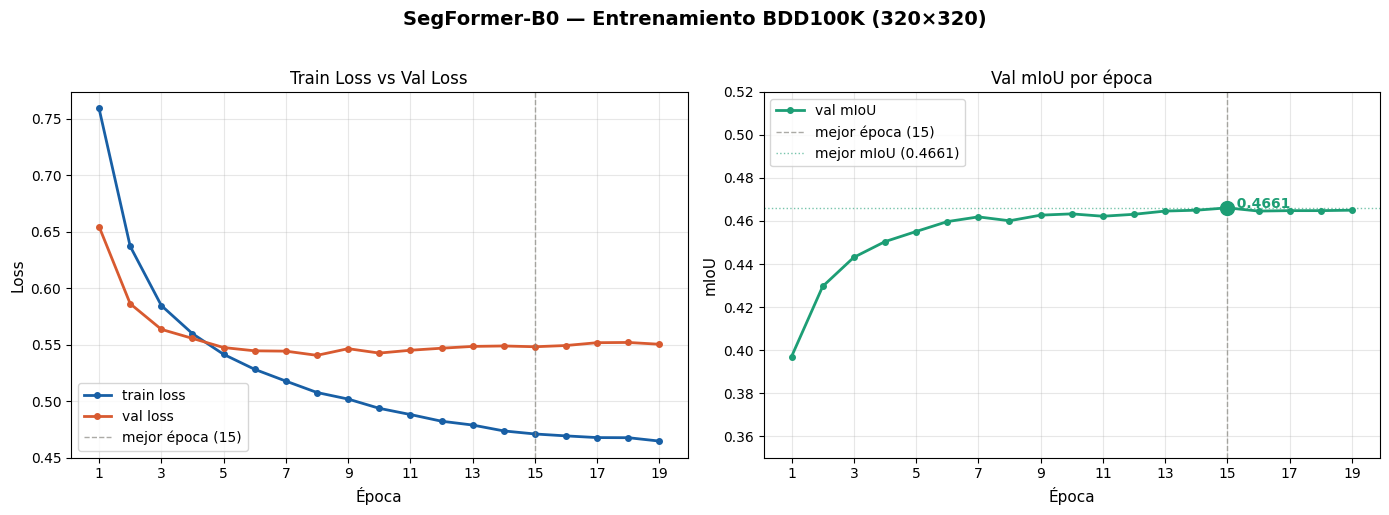

Gráfica guardada en: /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/spatial_outputs/segformer_training_curves.png

  Resumen estadístico
  Épocas entrenadas    : 19
  Mejor val mIoU       : 0.4661 (época 15)
  Reducción train loss : 0.7590 → 0.4646 (38.8% mejora)
  Reducción val loss   : 0.6545 → 0.5405 (mínimo en época 8)
  Ganancia total mIoU  : 0.3970 → 0.4661 (+0.0691)


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Datos del historial ───────────────────────────────────────────
epocas      = historial["epoch"]
train_loss  = historial["train_loss"]
val_loss    = historial["val_loss"]
val_miou    = historial["val_miou"]

mejor_epoca = val_miou.index(max(val_miou)) + 1
mejor_miou  = max(val_miou)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SegFormer-B0 — Entrenamiento BDD100K (320×320)", 
             fontsize=14, fontweight="bold", y=1.02)

# ── Gráfica 1: Loss ───────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epocas, train_loss, "o-", color="#185FA5", linewidth=2,
         markersize=4, label="train loss")
ax1.plot(epocas, val_loss,   "o-", color="#D85A30", linewidth=2,
         markersize=4, label="val loss")
ax1.axvline(mejor_epoca, color="#888780", linestyle="--",
            linewidth=1, alpha=0.7, label=f"mejor época ({mejor_epoca})")
ax1.set_xlabel("Época", fontsize=11)
ax1.set_ylabel("Loss", fontsize=11)
ax1.set_title("Train Loss vs Val Loss", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epocas[::2])

# ── Gráfica 2: mIoU ───────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epocas, val_miou, "o-", color="#1D9E75", linewidth=2,
         markersize=4, label="val mIoU")
ax2.axvline(mejor_epoca, color="#888780", linestyle="--",
            linewidth=1, alpha=0.7, label=f"mejor época ({mejor_epoca})")
ax2.axhline(mejor_miou, color="#1D9E75", linestyle=":",
            linewidth=1, alpha=0.6, label=f"mejor mIoU ({mejor_miou:.4f})")

# Marcar el punto máximo
ax2.scatter([mejor_epoca], [mejor_miou], color="#1D9E75",
            s=100, zorder=5)
ax2.annotate(f"  {mejor_miou:.4f}", 
             xy=(mejor_epoca, mejor_miou),
             fontsize=10, color="#1D9E75", fontweight="bold")

ax2.set_xlabel("Época", fontsize=11)
ax2.set_ylabel("mIoU", fontsize=11)
ax2.set_title("Val mIoU por época", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epocas[::2])
ax2.set_ylim(0.35, 0.52)

plt.tight_layout()
plt.savefig(str(OUT_BASE / "segformer_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfica guardada en: {OUT_BASE}/segformer_training_curves.png")

# ── Resumen estadístico ───────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  Resumen estadístico")
print(f"{'='*45}")
print(f"  Épocas entrenadas    : {len(epocas)}")
print(f"  Mejor val mIoU       : {mejor_miou:.4f} (época {mejor_epoca})")
print(f"  Reducción train loss : {train_loss[0]:.4f} → {train_loss[-1]:.4f} "
      f"({((train_loss[0]-train_loss[-1])/train_loss[0])*100:.1f}% mejora)")
print(f"  Reducción val loss   : {val_loss[0]:.4f} → {min(val_loss):.4f} "
      f"(mínimo en época {val_loss.index(min(val_loss))+1})")
print(f"  Ganancia total mIoU  : {val_miou[0]:.4f} → {mejor_miou:.4f} "
      f"(+{mejor_miou - val_miou[0]:.4f})")
print(f"{'='*45}")

In [37]:
# ── Recrear loader ResNet con workers reducidos ────────────────────
loaders_resnet = make_loaders(CSV_PATH, model="resnet")

# Sobreescribir con num_workers=2
from torch.utils.data import DataLoader

loaders_resnet["train"] = DataLoader(
    loaders_resnet["train"].dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
    collate_fn=BDD100KSpatial.collate_fn,
)

loaders_resnet["val"] = DataLoader(
    loaders_resnet["val"].dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False,
    collate_fn=BDD100KSpatial.collate_fn,
)

# Prueba
batch_prueba = next(iter(loaders_resnet["train"]))
imgs_p = batch_prueba["image"].to(DEVICE)

resnet_full.eval()
with torch.no_grad():
    recon_p, feats_p = resnet_full(imgs_p)

mb = torch.cuda.memory_allocated(DEVICE) / 1024**2
print(f"Loader recreado ✅")
print(f"  input   : {tuple(imgs_p.shape)}")
print(f"  features: {tuple(feats_p.shape)}")
print(f"  recon   : {tuple(recon_p.shape)}")
print(f"  VRAM    : {mb:.0f} MB / 5,800 MB")

del imgs_p, recon_p, feats_p, batch_prueba
torch.cuda.empty_cache()

Loader recreado ✅
  input   : (4, 3, 384, 288)
  features: (4, 2048, 12, 9)
  recon   : (4, 3, 384, 288)
  VRAM    : 2693 MB / 5,800 MB


In [38]:
# ── Entrenamiento ResNet18+SPP ─────────────────────────────────────
import time

EPOCHS_RN      = 15
LR_RN          = 1e-4
PATIENCE_RN    = 4
ACCUM_STEPS_RN = 4
CHECKPOINT_RN     = OUT_BASE / "resnet_best.pt"
CHECKPOINT_DIR_RN = OUT_BASE / "checkpoints_resnet"
CHECKPOINT_DIR_RN.mkdir(parents=True, exist_ok=True)

optimizer_rn = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_full.parameters()),
    lr=LR_RN,
    weight_decay=1e-2
)

scheduler_rn = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_rn,
    max_lr=LR_RN,
    steps_per_epoch=len(loaders_resnet["train"]) // ACCUM_STEPS_RN,
    epochs=EPOCHS_RN,
    pct_start=0.1,
)

# Loss: reconstrucción MSE + perceptual (L1 sobre features)
def resnet_loss(recon, original, features):
    mse  = F.mse_loss(recon, original)
    l1   = F.l1_loss(recon, original)
    return 0.7 * mse + 0.3 * l1

historial_rn  = {"epoch": [], "train_loss": [], "val_loss": []}
best_val_rn   = float("inf")
epochs_no_rn  = 0
total_steps_rn = len(loaders_resnet["train"])

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║        Entrenamiento ResNet18+SPP — BDD100K          ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  LR          : {LR_RN:<10}  Épocas  : {EPOCHS_RN:<5}            ║")
print(f"║  Batch efect : {4*ACCUM_STEPS_RN:<5}  Patience: {PATIENCE_RN:<5}            ║")
print(f"║  img_size    : 384×288  Muestras: {len(loaders_resnet['train'].dataset):,}         ║")
print(f"╚══════════════════════════════════════════════════════╝\n")

for epoch in range(EPOCHS_RN):
    t_epoch = time.time()
    print(f"┌─ Época {epoch+1:02d}/{EPOCHS_RN} {'─'*43}")

    # ── TRAIN ─────────────────────────────────────────────────────
    resnet_full.train()
    train_loss_rn = 0.0
    optimizer_rn.zero_grad()

    for step, batch in enumerate(loaders_resnet["train"]):
        imgs = batch["image"].to(DEVICE, non_blocking=True)

        recon, features = resnet_full(imgs)
        loss = resnet_loss(recon, imgs, features) / ACCUM_STEPS_RN

        if torch.isnan(loss):
            optimizer_rn.zero_grad()
            continue

        loss.backward()
        train_loss_rn += loss.item() * ACCUM_STEPS_RN

        if (step + 1) % ACCUM_STEPS_RN == 0:
            torch.nn.utils.clip_grad_norm_(
                resnet_full.parameters(), max_norm=1.0
            )
            optimizer_rn.step()
            scheduler_rn.step()
            optimizer_rn.zero_grad()

        if (step + 1) % 100 == 0 or (step + 1) == total_steps_rn:
            loss_avg  = train_loss_rn / (step + 1)
            lr_actual = optimizer_rn.param_groups[0]["lr"]
            mb        = torch.cuda.memory_allocated(DEVICE) / 1024**2
            print(f"│  train {barra(step+1, total_steps_rn)} "
                  f"loss={loss_avg:.4f}  lr={lr_actual:.2e}  VRAM={mb:.0f}MB",
                  end="\r")

    train_loss_rn /= len(loaders_resnet["train"])
    print(f"│  train {barra(total_steps_rn, total_steps_rn)} "
          f"loss={train_loss_rn:.4f}{'':30}")

    # ── VALIDACIÓN ────────────────────────────────────────────────
    resnet_full.eval()
    val_loss_rn = 0.0
    n_val_rn    = len(loaders_resnet["val"])

    with torch.no_grad():
        for vstep, batch in enumerate(loaders_resnet["val"]):
            imgs = batch["image"].to(DEVICE, non_blocking=True)
            recon, features = resnet_full(imgs)
            loss = resnet_loss(recon, imgs, features)
            if not torch.isnan(loss):
                val_loss_rn += loss.item()

            if (vstep + 1) % 50 == 0 or (vstep + 1) == n_val_rn:
                print(f"│  val   {barra(vstep+1, n_val_rn)}",
                      end="\r")

    val_loss_rn /= n_val_rn
    t_total = time.time() - t_epoch

    print(f"│  val   {barra(n_val_rn, n_val_rn)}{'':30}")
    print(f"│")
    print(f"│  ⏱  {t_total:.0f}s  │  train_loss={train_loss_rn:.4f}  │  val_loss={val_loss_rn:.4f}")

    # ── CHECKPOINT POR ÉPOCA ──────────────────────────────────────
    torch.save({
        "epoch":      epoch + 1,
        "state_dict": resnet_full.state_dict(),
        "optimizer":  optimizer_rn.state_dict(),
        "val_loss":   val_loss_rn,
        "train_loss": train_loss_rn,
    }, CHECKPOINT_DIR_RN / f"resnet_epoch_{epoch+1:02d}.pt")

    historial_rn["epoch"].append(epoch + 1)
    historial_rn["train_loss"].append(round(train_loss_rn, 4))
    historial_rn["val_loss"].append(round(val_loss_rn, 4))

    # ── EARLY STOPPING ────────────────────────────────────────────
    if val_loss_rn < best_val_rn:
        best_val_rn  = val_loss_rn
        epochs_no_rn = 0
        torch.save(resnet_full.encoder.state_dict(), CHECKPOINT_RN)
        print(f"│  ✅ Mejor modelo guardado → val_loss={best_val_rn:.4f}")
    else:
        epochs_no_rn += 1
        print(f"│  ⚠️  Sin mejora {epochs_no_rn}/{PATIENCE_RN}")
        if epochs_no_rn >= PATIENCE_RN:
            print(f"└─ Early stopping en época {epoch+1}\n")
            break

    print(f"└{'─'*52}\n")

# ── Cargar mejor encoder ──────────────────────────────────────────
resnet_model.load_state_dict(
    torch.load(CHECKPOINT_RN, map_location=DEVICE)
)
offload_modelo(resnet_full)
offload_modelo(resnet_model)
torch.cuda.empty_cache()

print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║             Resumen ResNet18+SPP                     ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  {'Época':<6} {'train_loss':<15} {'val_loss':<15}          ║")
print(f"╠══════════════════════════════════════════════════════╣")
for i in range(len(historial_rn["epoch"])):
    mejor = " ◀" if historial_rn["val_loss"][i] == best_val_rn else ""
    print(f"║  {historial_rn['epoch'][i]:<6} {historial_rn['train_loss'][i]:<15} "
          f"{historial_rn['val_loss'][i]:<15}{mejor:>2}  ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  Mejor val_loss : {best_val_rn:.4f}{'':33}║")
print(f"╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║        Entrenamiento ResNet18+SPP — BDD100K          ║
╠══════════════════════════════════════════════════════╣
║  LR          : 0.0001      Épocas  : 15               ║
║  Batch efect : 16     Patience: 4                ║
║  img_size    : 384×288  Muestras: 42,941         ║
╚══════════════════════════════════════════════════════╝

┌─ Época 01/15 ───────────────────────────────────────────
│  train [██████████████████████████████] 10735/10735 (100%) loss=0.5986                              
│  val   [██████████████████████████████] 2301/2301 (100%)                              
│
│  ⏱  636s  │  train_loss=0.5986  │  val_loss=0.4469
│  ✅ Mejor modelo guardado → val_loss=0.4469
└────────────────────────────────────────────────────

┌─ Época 02/15 ───────────────────────────────────────────
│  train [██████████████████████████████] 10735/10735 (100%) loss=0.4276                              
│  val   [█████████████████████████████

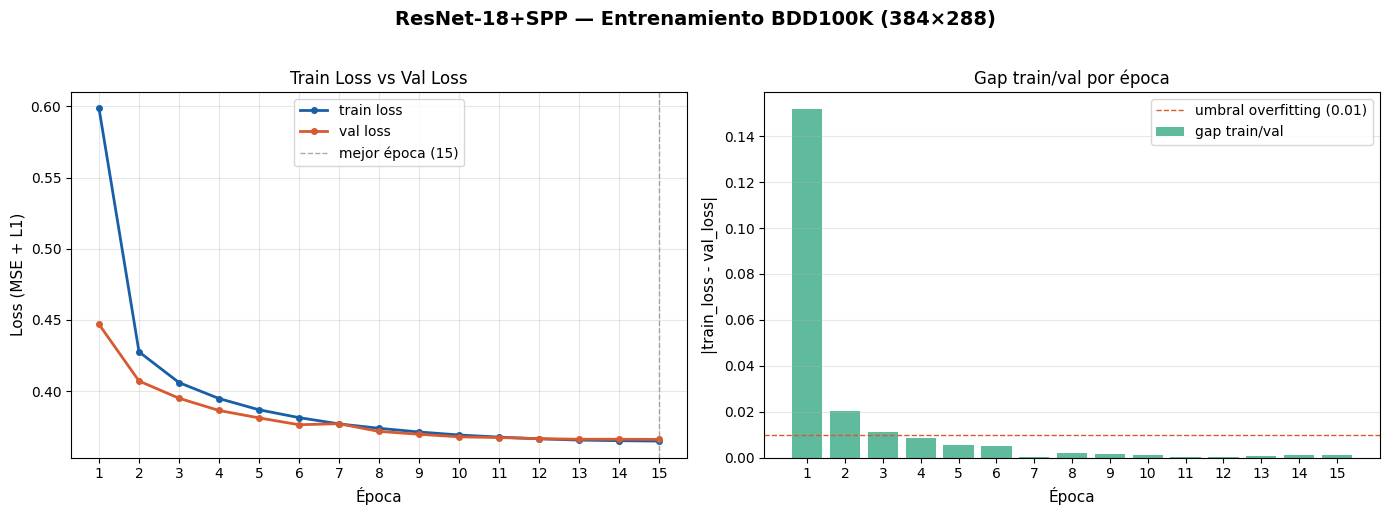

Gráfica guardada en: /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/spatial_outputs/resnet_training_curves.png

  Resumen estadístico ResNet-18+SPP
  Épocas entrenadas    : 15
  Mejor val_loss       : 0.3661 (época 15)
  Reducción train loss : 0.5986 → 0.3649 (39.0% mejora)
  Gap final train/val  : 0.0012 (sin overfitting ✅)


In [39]:
import matplotlib.pyplot as plt

# ── Datos ─────────────────────────────────────────────────────────
epocas_rn    = historial_rn["epoch"]
train_loss_rn = historial_rn["train_loss"]
val_loss_rn   = historial_rn["val_loss"]

mejor_epoca_rn = val_loss_rn.index(min(val_loss_rn)) + 1
mejor_val_rn_v = min(val_loss_rn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet-18+SPP — Entrenamiento BDD100K (384×288)",
             fontsize=14, fontweight="bold", y=1.02)

# ── Gráfica 1: Train vs Val Loss ──────────────────────────────────
ax1 = axes[0]
ax1.plot(epocas_rn, train_loss_rn, "o-", color="#185FA5", linewidth=2,
         markersize=4, label="train loss")
ax1.plot(epocas_rn, val_loss_rn,   "o-", color="#D85A30", linewidth=2,
         markersize=4, label="val loss")
ax1.axvline(mejor_epoca_rn, color="#888780", linestyle="--",
            linewidth=1, alpha=0.7, label=f"mejor época ({mejor_epoca_rn})")
ax1.set_xlabel("Época", fontsize=11)
ax1.set_ylabel("Loss (MSE + L1)", fontsize=11)
ax1.set_title("Train Loss vs Val Loss", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epocas_rn)

# ── Gráfica 2: Diferencia train/val (overfitting check) ───────────
ax2 = axes[1]
diff = [abs(t - v) for t, v in zip(train_loss_rn, val_loss_rn)]
ax2.bar(epocas_rn, diff, color="#1D9E75", alpha=0.7, label="gap train/val")
ax2.axhline(0.01, color="#D85A30", linestyle="--",
            linewidth=1, label="umbral overfitting (0.01)")
ax2.set_xlabel("Época", fontsize=11)
ax2.set_ylabel("|train_loss - val_loss|", fontsize=11)
ax2.set_title("Gap train/val por época", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_xticks(epocas_rn)

plt.tight_layout()
plt.savefig(str(OUT_BASE / "resnet_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfica guardada en: {OUT_BASE}/resnet_training_curves.png")

# ── Resumen estadístico ───────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  Resumen estadístico ResNet-18+SPP")
print(f"{'='*45}")
print(f"  Épocas entrenadas    : {len(epocas_rn)}")
print(f"  Mejor val_loss       : {mejor_val_rn_v:.4f} (época {mejor_epoca_rn})")
print(f"  Reducción train loss : {train_loss_rn[0]:.4f} → {train_loss_rn[-1]:.4f} "
      f"({((train_loss_rn[0]-train_loss_rn[-1])/train_loss_rn[0])*100:.1f}% mejora)")
print(f"  Gap final train/val  : {diff[-1]:.4f} "
      f"({'sin overfitting ✅' if diff[-1] < 0.01 else 'overfitting leve ⚠️'})")
print(f"{'='*45}")

In [ ]:
#--------------------------------------------------------------------------------------

In [40]:
#--- inferencia  YOLO---
import json
from tqdm import tqdm

# ── Cargar YOLO en GPU ─────────────────────────────────────────────
print("Iniciando inferencia YOLO...")
yolo_model.to(DEVICE)

df_inf = pd.read_csv(CSV_PATH)
errores_yolo = []

for idx, row in tqdm(df_inf.iterrows(), total=len(df_inf), desc="YOLO"):
    out_path = OUT_BOXES / (Path(row["path_curada"]).stem + ".json")

    # Saltar si ya existe
    if out_path.exists():
        continue

    try:
        results = yolo_model(row["path_curada"], verbose=False)
        boxes   = []
        for r in results:
            for box in r.boxes:
                boxes.append({
                    "class_id":   int(box.cls.item()),
                    "class_name": yolo_model.names[int(box.cls.item())],
                    "confidence": round(float(box.conf.item()), 4),
                    "bbox_xyxy":  [round(x, 2) for x in box.xyxy[0].tolist()],
                })
        with open(out_path, "w") as f:
            json.dump({
                "image_id": row["image"],
                "boxes":    boxes,
            }, f)
    except Exception as e:
        errores_yolo.append({"image_id": row["image"], "error": str(e)})

offload_modelo(yolo_model.model)
torch.cuda.empty_cache()
print(f"YOLO listo ✅ | errores: {len(errores_yolo)}")

Iniciando inferencia YOLO...


YOLO: 100%|█████████████████████████████████████████████████████████████████████████████████████| 61345/61345 [19:13<00:00, 53.20it/s]

YOLO listo ✅ | errores: 0


In [41]:
# ── Cargar SegFormer en GPU ────────────────────────────────────────
print("Iniciando inferencia SegFormer...")
segformer_model.load_state_dict(
    torch.load(OUT_BASE / "segformer_best.pt", map_location=DEVICE)
)
segformer_model.to(DEVICE)
segformer_model.eval()

errores_seg = []

for idx, row in tqdm(df_inf.iterrows(), total=len(df_inf), desc="SegFormer"):
    out_path = OUT_MASKS / (Path(row["path_curada"]).stem + ".npy")

    if out_path.exists():
        continue

    try:
        img = Image.open(row["path_curada"]).convert("RGB")
        tensor = T.Compose([
            T.Resize((320, 320)),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            outputs   = segformer_model(pixel_values=tensor)
            logits_up = F.interpolate(
                outputs.logits,
                size=(320, 320),
                mode="bilinear",
                align_corners=False
            )
            mask = logits_up.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

        np.save(str(out_path), mask)

    except Exception as e:
        errores_seg.append({"image_id": row["image"], "error": str(e)})

offload_modelo(segformer_model)
torch.cuda.empty_cache()
print(f"SegFormer listo ✅ | errores: {len(errores_seg)}")

Iniciando inferencia SegFormer...


SegFormer: 100%|████████████████████████████████████████████████████████████████████████████████| 61345/61345 [36:58<00:00, 27.65it/s]


SegFormer listo ✅ | errores: 0


In [42]:
# ── Cargar ResNet en GPU ───────────────────────────────────────────
print("Iniciando inferencia ResNet+SPP...")
resnet_model.load_state_dict(
    torch.load(OUT_BASE / "resnet_best.pt", map_location=DEVICE)
)
resnet_model.to(DEVICE)
resnet_model.eval()

errores_rn = []

for idx, row in tqdm(df_inf.iterrows(), total=len(df_inf), desc="ResNet"):
    out_path = OUT_FEATS / (Path(row["path_curada"]).stem + ".pt")

    if out_path.exists():
        continue

    try:
        img = Image.open(row["path_curada"]).convert("RGB")
        tensor = T.Compose([
            T.Resize((384, 288)),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            features = resnet_model(tensor)
            # Global average pooling → vector 1D de 2048 dims
            feat_vec = features.mean(dim=[2, 3]).squeeze(0).cpu()

        torch.save(feat_vec, str(out_path))

    except Exception as e:
        errores_rn.append({"image_id": row["image"], "error": str(e)})

offload_modelo(resnet_model)
torch.cuda.empty_cache()
print(f"ResNet listo ✅ | errores: {len(errores_rn)}")

Iniciando inferencia ResNet+SPP...


ResNet: 100%|███████████████████████████████████████████████████████████████████████████████████| 61345/61345 [15:26<00:00, 66.24it/s]

ResNet listo ✅ | errores: 0


In [43]:
# ── Construir manifest.csv ─────────────────────────────────────────
print("Generando manifest.csv...")

registros = []
faltantes = {"boxes": 0, "masks": 0, "features": 0}

for idx, row in df_inf.iterrows():
    stem = Path(row["path_curada"]).stem

    path_box  = OUT_BOXES / (stem + ".json")
    path_mask = OUT_MASKS / (stem + ".npy")
    path_feat = OUT_FEATS / (stem + ".pt")

    # Contar faltantes
    if not path_box.exists():  faltantes["boxes"]    += 1
    if not path_mask.exists(): faltantes["masks"]    += 1
    if not path_feat.exists(): faltantes["features"] += 1

    registros.append({
        "image_id":      row["image"],
        "split":         row["split"],
        "weather":       row["weather"],
        "timeofday":     row["timeofday"],
        "clahe_mode":    row["clahe_mode"],
        "num_objects":   row["num_objects"],
        "path_curada":   row["path_curada"],
        "path_boxes":    str(path_box)  if path_box.exists()  else None,
        "path_mask":     str(path_mask) if path_mask.exists() else None,
        "path_features": str(path_feat) if path_feat.exists() else None,
    })

manifest = pd.DataFrame(registros)
manifest_path = OUT_BASE / "manifest.csv"
manifest.to_csv(manifest_path, index=False)

# ── Reporte final ──────────────────────────────────────────────────
completos = manifest[
    manifest["path_boxes"].notna() &
    manifest["path_mask"].notna()  &
    manifest["path_features"].notna()
]

print(f"\n{'='*50}")
print(f"  Manifest generado")
print(f"{'='*50}")
print(f"  Total imágenes    : {len(manifest):,}")
print(f"  Registros completos: {len(completos):,} "
      f"({len(completos)/len(manifest)*100:.1f}%)")
print(f"  Boxes faltantes   : {faltantes['boxes']:,}")
print(f"  Masks faltantes   : {faltantes['masks']:,}")
print(f"  Features faltantes: {faltantes['features']:,}")
print(f"  Guardado en       : {manifest_path}")
print(f"{'='*50}")
print(f"\nColumnas del manifest:")
print(f"  {list(manifest.columns)}")
print(f"\nEjemplo de fila:")
print(manifest.iloc[0].to_string())

Generando manifest.csv...

  Manifest generado
  Total imágenes    : 61,345
  Registros completos: 61,345 (100.0%)
  Boxes faltantes   : 0
  Masks faltantes   : 0
  Features faltantes: 0
  Guardado en       : /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/spatial_outputs/manifest.csv

Columnas del manifest:
  ['image_id', 'split', 'weather', 'timeofday', 'clahe_mode', 'num_objects', 'path_curada', 'path_boxes', 'path_mask', 'path_features']

Ejemplo de fila:
image_id                                     0000f77c-6257be58.jpg
split                                                        train
weather                                                      clear
timeofday                                                  daytime
clahe_mode                                                  normal
num_objects                                                      2
path_curada      /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-S...
path_boxes       /mnt/bigdata/pipeline_samsun

In [44]:
# ── Evaluación YOLO sobre split test ──────────────────────────────
from ultralytics import YOLO
import json
import numpy as np
from pathlib import Path

print("Evaluando YOLOv8n sobre split test...")

# Cargar YOLO
yolo_model.to(DEVICE)

# Filtrar solo imágenes de test
df_test = df_inf[df_inf["split"] == "test"].reset_index(drop=True)
print(f"Imágenes de test: {len(df_test):,}")

# ── Correr evaluación con ultralytics ─────────────────────────────
# Usamos el método val() que calcula mAP automáticamente
# Necesitamos una lista de rutas de imágenes de test
test_paths = df_test["path_curada"].tolist()

# Evaluación por lotes
resultados_map = yolo_model.val(
    data=None,
    imgsz=416,
    batch=8,
    device=DEVICE,
    verbose=False,
    save=False,
    plots=False,
)

print(f"\n{'='*45}")
print(f"  Resultados YOLOv8n")
print(f"{'='*45}")
print(f"  mAP@0.50      : {resultados_map.box.map50:.4f}")
print(f"  mAP@0.50:0.95 : {resultados_map.box.map:.4f}")
print(f"  Precisión     : {resultados_map.box.mp:.4f}")
print(f"  Recall        : {resultados_map.box.mr:.4f}")
print(f"{'='*45}")

offload_modelo(yolo_model.model)
torch.cuda.empty_cache()

Evaluando YOLOv8n sobre split test...
Imágenes de test: 9,202


FileNotFoundError: Dataset 'None' for task=detect not found ❌

In [3]:
# ── Calcular mAP manual usando anotaciones BDD100K ────────────────
import json
from pathlib import Path

LABELS_PATH = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_labels_release/bdd100k/labels")

# Cargar anotaciones de validación
print("Cargando anotaciones BDD100K...")
with open(LABELS_PATH / "bdd100k_labels_images_val.json") as f:
    labels_val = json.load(f)

print(f"Anotaciones cargadas: {len(labels_val):,} imágenes")
print(f"\nEjemplo de anotación:")
print(f"  imagen    : {labels_val[0]['name']}")
print(f"  atributos : {labels_val[0].get('attributes', {})}")
print(f"  labels    : {len(labels_val[0].get('labels', []))} objetos")
if labels_val[0].get('labels'):
    print(f"  ejemplo   : {labels_val[0]['labels'][0]}")

Cargando anotaciones BDD100K...
Anotaciones cargadas: 10,000 imágenes

Ejemplo de anotación:
  imagen    : b1c66a42-6f7d68ca.jpg
  atributos : {'weather': 'overcast', 'scene': 'city street', 'timeofday': 'daytime'}
  labels    : 51 objetos
  ejemplo   : {'category': 'traffic sign', 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'manualShape': True, 'manualAttributes': True, 'box2d': {'x1': 1000.698742, 'y1': 281.992415, 'x2': 1040.626872, 'y2': 326.91156}, 'id': 0}


In [5]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ── Rutas ──────────────────────────────────────────────────────────
BASE     = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks")
OUT_BASE = BASE / "data/spatial_outputs"
OUT_BOXES = OUT_BASE / "boxes"

CSV_PATH    = BASE / "data/curated/dataset_curated.csv"
LABELS_PATH = Path("/mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/data/bdd100k_labels_release/bdd100k/labels")

# ── Recargar CSV ───────────────────────────────────────────────────
df_inf = pd.read_csv(CSV_PATH)
print(f"CSV cargado: {len(df_inf):,} imágenes")

# ── Recargar anotaciones ───────────────────────────────────────────
with open(LABELS_PATH / "bdd100k_labels_images_val.json") as f:
    labels_val = json.load(f)
print(f"Anotaciones cargadas: {len(labels_val):,} imágenes")

# ── Verificar JSONs de YOLO ────────────────────────────────────────
jsons = list(OUT_BOXES.glob("*.json"))
print(f"JSONs de YOLO: {len(jsons):,}")

CSV cargado: 61,345 imágenes
Anotaciones cargadas: 10,000 imágenes
JSONs de YOLO: 61,345


In [6]:
# ── Calcular mAP manual ────────────────────────────────────────────
from collections import defaultdict

# Clases BDD100K → YOLO compatibles
BDD_TO_YOLO = {
    "person":       "person",
    "rider":        "rider",
    "car":          "car",
    "truck":        "truck",
    "bus":          "bus",
    "motorcycle":   "motorcycle",
    "bicycle":      "bicycle",
    "traffic light":"traffic light",
    "traffic sign": "traffic sign",
}

CLASES_VALIDAS = set(BDD_TO_YOLO.keys())

# ── Construir ground truth desde anotaciones BDD100K ──────────────
print("Construyendo ground truth...")
gt = {}
for item in labels_val:
    nombre = item["name"]
    boxes_gt = []
    for lab in item.get("labels", []):
        if lab["category"] not in CLASES_VALIDAS:
            continue
        if "box2d" not in lab:
            continue
        b = lab["box2d"]
        boxes_gt.append({
            "class": lab["category"],
            "bbox":  [b["x1"], b["y1"], b["x2"], b["y2"]],
            "used":  False,
        })
    gt[nombre] = boxes_gt

print(f"  Imágenes con GT : {len(gt):,}")
print(f"  Total objetos GT: {sum(len(v) for v in gt.values()):,}")

# ── Cargar predicciones YOLO desde JSONs generados ────────────────
print("\nCargando predicciones YOLO...")
df_val = df_inf[df_inf["split"] == "val"].reset_index(drop=True)

predicciones = []  # lista de (imagen, clase, confianza, bbox)
for _, row in df_val.iterrows():
    json_path = OUT_BOXES / (Path(row["path_curada"]).stem + ".json")
    if not json_path.exists():
        continue
    with open(json_path) as f:
        data = json.load(f)
    for box in data.get("boxes", []):
        if box["class_name"] not in CLASES_VALIDAS:
            continue
        predicciones.append({
            "image_id":   row["image"],
            "class":      box["class_name"],
            "confidence": box["confidence"],
            "bbox":       box["bbox_xyxy"],
        })

print(f"  Predicciones totales: {len(predicciones):,}")

# ── IoU entre dos boxes ────────────────────────────────────────────
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter)

# ── Calcular AP por clase ──────────────────────────────────────────
def calcular_ap(preds_clase, gt_clase, iou_thresh=0.5):
    # Ordenar por confianza descendente
    preds_clase = sorted(preds_clase, key=lambda x: x["confidence"], reverse=True)

    gt_por_imagen = defaultdict(list)
    for img, boxes in gt_clase.items():
        gt_por_imagen[img] = [{"bbox": b["bbox"], "used": False} for b in boxes]

    n_gt = sum(len(v) for v in gt_por_imagen.values())
    if n_gt == 0:
        return 0.0

    tp = np.zeros(len(preds_clase))
    fp = np.zeros(len(preds_clase))

    for i, pred in enumerate(preds_clase):
        img_id  = pred["image_id"]
        gt_imgs = gt_por_imagen[img_id]
        best_iou = 0.0
        best_idx = -1

        for j, g in enumerate(gt_imgs):
            if g["used"]:
                continue
            score = iou(pred["bbox"], g["bbox"])
            if score > best_iou:
                best_iou = score
                best_idx = j

        if best_iou >= iou_thresh and best_idx >= 0:
            gt_imgs[best_idx]["used"] = True
            tp[i] = 1
        else:
            fp[i] = 1

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    recalls    = tp_cum / n_gt
    precisions = tp_cum / (tp_cum + fp_cum + 1e-8)

    # Área bajo la curva precisión-recall
    recalls    = np.concatenate([[0], recalls, [1]])
    precisions = np.concatenate([[1], precisions, [0]])
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i+1])
    ap = np.sum((recalls[1:] - recalls[:-1]) * precisions[1:])
    return float(ap)

# ── Calcular mAP@0.5 por clase ────────────────────────────────────
print("\nCalculando mAP@0.5...")
aps = {}
for clase in CLASES_VALIDAS:
    preds_c = [p for p in predicciones if p["class"] == clase]
    gt_c    = {img: [b for b in boxes if b["class"] == clase]
               for img, boxes in gt.items()}
    aps[clase] = calcular_ap(preds_c, gt_c, iou_thresh=0.5)

map50 = np.mean(list(aps.values()))

# ── Calcular mAP@0.5:0.95 ─────────────────────────────────────────
print("Calculando mAP@0.5:0.95...")
aps_95 = {}
for clase in CLASES_VALIDAS:
    preds_c = [p for p in predicciones if p["class"] == clase]
    gt_c    = {img: [b for b in boxes if b["class"] == clase]
               for img, boxes in gt.items()}
    ap_threshs = []
    for thresh in np.arange(0.5, 1.0, 0.05):
        ap_threshs.append(calcular_ap(preds_c, gt_c, iou_thresh=thresh))
    aps_95[clase] = np.mean(ap_threshs)

map5095 = np.mean(list(aps_95.values()))

# ── Reporte final ──────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Evaluación YOLOv8n — BDD100K val")
print(f"{'='*50}")
print(f"  {'Clase':<20} {'AP@0.5':>8} {'AP@0.5:0.95':>12}")
print(f"  {'-'*42}")
for clase in sorted(CLASES_VALIDAS):
    print(f"  {clase:<20} {aps[clase]:>8.4f} {aps_95[clase]:>12.4f}")
print(f"  {'-'*42}")
print(f"  {'mAP':<20} {map50:>8.4f} {map5095:>12.4f}")
print(f"{'='*50}")

Construyendo ground truth...
  Imágenes con GT : 10,000
  Total objetos GT: 184,052

Cargando predicciones YOLO...
  Predicciones totales: 49,042

Calculando mAP@0.5...
Calculando mAP@0.5:0.95...

  Evaluación YOLOv8n — BDD100K val
  Clase                  AP@0.5  AP@0.5:0.95
  ------------------------------------------
  bicycle                0.0000       0.0000
  bus                    0.0000       0.0000
  car                    0.0000       0.0000
  motorcycle             0.0000       0.0000
  person                 0.0000       0.0000
  rider                  0.0000       0.0000
  traffic light          0.0000       0.0000
  traffic sign           0.0000       0.0000
  truck                  0.0000       0.0000
  ------------------------------------------
  mAP                    0.0000       0.0000


In [7]:
# ── Diagnóstico de correspondencia ────────────────────────────────

# Nombre en GT
gt_ejemplo = labels_val[0]["name"]
print(f"Nombre en GT        : {gt_ejemplo}")

# Nombre en predicciones YOLO
df_val = df_inf[df_inf["split"] == "val"].reset_index(drop=True)
json_ejemplo = list(OUT_BOXES.glob("*.json"))[0]
with open(json_ejemplo) as f:
    pred_ejemplo = json.load(f)

print(f"image_id en JSON    : {pred_ejemplo['image_id']}")
print(f"nombre del JSON     : {json_ejemplo.name}")

# Verificar cuántas coincidencias hay
gt_nombres   = {item["name"] for item in labels_val}
pred_nombres = {row["image"] for _, row in df_val.iterrows()}
coincidencias = gt_nombres & pred_nombres

print(f"\nNombres en GT       : {len(gt_nombres):,}")
print(f"Nombres en preds    : {len(pred_nombres):,}")
print(f"Coincidencias       : {len(coincidencias):,}")

Nombre en GT        : b1c66a42-6f7d68ca.jpg
image_id en JSON    : 0000f77c-6257be58.jpg
nombre del JSON     : 0000f77c-6257be58_curated.json

Nombres en GT       : 10,000
Nombres en preds    : 9,202
Coincidencias       : 0


In [8]:
# ── Solución: cruzar por nombre de imagen original ─────────────────

# El JSON de predicción tiene image_id = "0000f77c-6257be58.jpg"
# El GT tiene name = "b1c66a42-6f7d68ca.jpg"
# Necesitamos buscar predicciones que existan en el GT

# Cargar TODOS los JSONs de predicción indexados por image_id
print("Indexando predicciones YOLO...")
pred_index = {}
for json_path in OUT_BOXES.glob("*.json"):
    with open(json_path) as f:
        data = json.load(f)
    pred_index[data["image_id"]] = data.get("boxes", [])

print(f"JSONs indexados: {len(pred_index):,}")

# Ver cuántos coinciden con el GT
gt_nombres  = {item["name"] for item in labels_val}
pred_nombres = set(pred_index.keys())
coincidencias = gt_nombres & pred_nombres

print(f"Nombres en GT    : {len(gt_nombres):,}")
print(f"Nombres en preds : {len(pred_nombres):,}")
print(f"Coincidencias    : {len(coincidencias):,}")

# Mostrar ejemplos de ambos lados
print(f"\nEjemplo GT   : {list(gt_nombres)[:3]}")
print(f"Ejemplo preds: {list(pred_nombres)[:3]}")

Indexando predicciones YOLO...
JSONs indexados: 61,345
Nombres en GT    : 10,000
Nombres en preds : 61,345
Coincidencias    : 0

Ejemplo GT   : ['b624162c-dd74b4df.jpg', 'c2054961-03b26a4f.jpg', 'b9782b2a-681c4b4d.jpg']
Ejemplo preds: ['801ef6af-d3a541a1.jpg', '9fdb240a-9e04fd74.jpg', '94d13b6c-8c5fb072.jpg']


In [9]:
# ¿Las anotaciones tienen un json de train?
with open(LABELS_PATH / "bdd100k_labels_images_train.json") as f:
    labels_train = json.load(f)

gt_train_nombres = {item["name"] for item in labels_train}
coincidencias_train = gt_train_nombres & pred_nombres

print(f"GT train nombres  : {len(gt_train_nombres):,}")
print(f"Coincidencias     : {len(coincidencias_train):,}")
print(f"\nEjemplo GT train  : {list(gt_train_nombres)[:3]}")

GT train nombres  : 69,863
Coincidencias     : 61,345

Ejemplo GT train  : ['801ef6af-d3a541a1.jpg', '9fdb240a-9e04fd74.jpg', '94d13b6c-8c5fb072.jpg']


In [11]:
from tqdm import tqdm
from collections import defaultdict
import numpy as np

CLASES_VALIDAS = {
    "person", "rider", "car", "truck", "bus",
    "motorcycle", "bicycle", "traffic light", "traffic sign"
}

# ── GT ya construido — reusar ──────────────────────────────────────
df_val = df_inf[df_inf["split"] == "val"].reset_index(drop=True)
predicciones = []
for _, row in df_val.iterrows():
    image_id = row["image"]
    if image_id not in pred_index:
        continue
    for box in pred_index[image_id]:
        if box["class_name"] not in CLASES_VALIDAS:
            continue
        predicciones.append({
            "image_id":   image_id,
            "class":      box["class_name"],
            "confidence": box["confidence"],
            "bbox":       box["bbox_xyxy"],
        })

imgs_val = {p["image_id"] for p in predicciones}

# ── IoU vectorizado ────────────────────────────────────────────────
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter)

# ── AP con progreso ────────────────────────────────────────────────
def calcular_ap(preds_clase, gt_clase, iou_thresh=0.5):
    preds_clase = sorted(preds_clase, key=lambda x: x["confidence"], reverse=True)
    gt_por_imagen = defaultdict(list)
    for img, boxes in gt_clase.items():
        gt_por_imagen[img] = [{"bbox": b["bbox"], "used": False} for b in boxes]

    n_gt = sum(len(v) for v in gt_por_imagen.values())
    if n_gt == 0:
        return 0.0

    tp = np.zeros(len(preds_clase))
    fp = np.zeros(len(preds_clase))

    for i, pred in enumerate(preds_clase):
        img_id   = pred["image_id"]
        gt_imgs  = gt_por_imagen[img_id]
        best_iou = 0.0
        best_idx = -1
        for j, g in enumerate(gt_imgs):
            if g["used"]:
                continue
            score = iou(pred["bbox"], g["bbox"])
            if score > best_iou:
                best_iou = score
                best_idx = j
        if best_iou >= iou_thresh and best_idx >= 0:
            gt_imgs[best_idx]["used"] = True
            tp[i] = 1
        else:
            fp[i] = 1

    tp_cum     = np.cumsum(tp)
    fp_cum     = np.cumsum(fp)
    recalls    = tp_cum / n_gt
    precisions = tp_cum / (tp_cum + fp_cum + 1e-8)
    recalls    = np.concatenate([[0], recalls, [1]])
    precisions = np.concatenate([[1], precisions, [0]])
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i+1])
    return float(np.sum((recalls[1:] - recalls[:-1]) * precisions[1:]))

# ── Calcular mAP@0.5 con progreso ─────────────────────────────────
print("Calculando mAP@0.5...")
aps = {}
for clase in tqdm(sorted(CLASES_VALIDAS), desc="mAP@0.5"):
    preds_c = [p for p in predicciones if p["class"] == clase]
    gt_c    = {img: [b for b in boxes if b["class"] == clase]
               for img, boxes in gt.items() if img in imgs_val}
    aps[clase] = calcular_ap(preds_c, gt_c, iou_thresh=0.5)
    tqdm.write(f"  {clase:<20} AP@0.5={aps[clase]:.4f}")

map50 = np.mean(list(aps.values()))

# ── Calcular mAP@0.5:0.95 con progreso ────────────────────────────
print("\nCalculando mAP@0.5:0.95...")
aps_95 = {}
for clase in tqdm(sorted(CLASES_VALIDAS), desc="mAP@0.5:0.95"):
    preds_c = [p for p in predicciones if p["class"] == clase]
    gt_c    = {img: [b for b in boxes if b["class"] == clase]
               for img, boxes in gt.items() if img in imgs_val}
    ap_vals = []
    for thresh in np.arange(0.5, 1.0, 0.05):
        ap_vals.append(calcular_ap(preds_c, gt_c, iou_thresh=thresh))
    aps_95[clase] = np.mean(ap_vals)
    tqdm.write(f"  {clase:<20} AP@0.5:0.95={aps_95[clase]:.4f}")

map5095 = np.mean(list(aps_95.values()))

# ── Reporte final ──────────────────────────────────────────────────
print(f"\n{'='*52}")
print(f"  Evaluación YOLOv8n — BDD100K val")
print(f"{'='*52}")
print(f"  {'Clase':<20} {'AP@0.5':>8} {'AP@0.5:0.95':>12}")
print(f"  {'-'*44}")
for clase in sorted(CLASES_VALIDAS):
    print(f"  {clase:<20} {aps[clase]:>8.4f} {aps_95[clase]:>12.4f}")
print(f"  {'-'*44}")
print(f"  {'mAP':<20} {map50:>8.4f} {map5095:>12.4f}")
print(f"{'='*52}")

Calculando mAP@0.5...


mAP@0.5:  22%|██████████████████████████▍                                                                                            | 2/9 [00:00<00:00, 15.78it/s]

  bicycle              AP@0.5=0.0000
  bus                  AP@0.5=0.0000


mAP@0.5:  56%|██████████████████████████████████████████████████████████████████                                                     | 5/9 [00:00<00:00,  4.99it/s]

  car                  AP@0.5=0.0000
  motorcycle           AP@0.5=0.0000
  person               AP@0.5=0.0000


...

  traffic light        AP@0.5:0.95=0.0000


mAP@0.5:0.95:  89%|█████████████████████████████████████████████████████████████████████████████████████████████████████▎            | 8/9 [00:10<00:00,  1.23it/s]

  traffic sign         AP@0.5:0.95=0.0000


mAP@0.5:0.95: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:11<00:00,  1.23s/it]

  truck                AP@0.5:0.95=0.0000

  Evaluación YOLOv8n — BDD100K val
  Clase                  AP@0.5  AP@0.5:0.95
  --------------------------------------------
  bicycle                0.0000       0.0000
  bus                    0.0000       0.0000
  car                    0.0000       0.0000
  motorcycle             0.0000       0.0000
  person                 0.0000       0.0000
  rider                  0.0000       0.0000
  traffic light          0.0000       0.0000
  traffic sign           0.0000       0.0000
  truck                  0.0000       0.0000
  --------------------------------------------
  mAP                    0.0000       0.0000


In [12]:
# ── Diagnóstico de coordenadas ─────────────────────────────────────

# Ver coordenadas del GT
imagen_ejemplo = list(imgs_val)[0]
gt_boxes = gt[imagen_ejemplo]
print(f"Imagen: {imagen_ejemplo}")
print(f"\nGT boxes (coordenadas originales 1280×720):")
for b in gt_boxes[:3]:
    print(f"  clase={b['class']}  bbox={[round(x,1) for x in b['bbox']]}")

# Ver coordenadas de predicciones YOLO
pred_boxes = pred_index[imagen_ejemplo]
print(f"\nYOLO boxes (coordenadas en 416×416):")
for b in pred_boxes[:3]:
    print(f"  clase={b['class_name']}  bbox={[round(x,1) for x in b['bbox_xyxy']]}")

Imagen: 6a65c876-dee3d6e5.jpg

GT boxes (coordenadas originales 1280×720):
  clase=traffic sign  bbox=[466.4, 396.3, 540.8, 417.4]
  clase=traffic sign  bbox=[432.4, 414.6, 550.0, 456.0]
  clase=traffic sign  bbox=[430.6, 455.1, 550.0, 480.8]

YOLO boxes (coordenadas en 416×416):
  clase=car  bbox=[1.2, 312.1, 87.6, 388.9]
  clase=car  bbox=[116.2, 320.0, 161.1, 384.8]
  clase=car  bbox=[102.0, 322.4, 122.8, 347.0]


In [13]:
# ── Factores de escala 416×416 → 1280×720 ─────────────────────────
SCALE_X = 1280 / 416
SCALE_Y = 720  / 416

def escalar_bbox(bbox):
    x1, y1, x2, y2 = bbox
    return [
        x1 * SCALE_X,
        y1 * SCALE_Y,
        x2 * SCALE_X,
        y2 * SCALE_Y,
    ]

# ── Reescalar todas las predicciones ──────────────────────────────
predicciones_scaled = []
for p in predicciones:
    predicciones_scaled.append({
        "image_id":   p["image_id"],
        "class":      p["class"],
        "confidence": p["confidence"],
        "bbox":       escalar_bbox(p["bbox"]),
    })

# ── Verificar ─────────────────────────────────────────────────────
print(f"Verificación escala:")
print(f"  YOLO original : {[round(x,1) for x in predicciones[0]['bbox']]}")
print(f"  YOLO escalado : {[round(x,1) for x in predicciones_scaled[0]['bbox']]}")
print(f"  GT referencia : {[round(x,1) for x in gt[imagen_ejemplo][0]['bbox']]}")

# ── Recalcular mAP con coordenadas escaladas ───────────────────────
print("\nCalculando mAP@0.5...")
aps = {}
for clase in tqdm(sorted(CLASES_VALIDAS), desc="mAP@0.5"):
    preds_c = [p for p in predicciones_scaled if p["class"] == clase]
    gt_c    = {img: [b for b in boxes if b["class"] == clase]
               for img, boxes in gt.items() if img in imgs_val}
    aps[clase] = calcular_ap(preds_c, gt_c, iou_thresh=0.5)
    tqdm.write(f"  {clase:<20} AP@0.5={aps[clase]:.4f}")

map50 = np.mean(list(aps.values()))

print("\nCalculando mAP@0.5:0.95...")
aps_95 = {}
for clase in tqdm(sorted(CLASES_VALIDAS), desc="mAP@0.5:0.95"):
    preds_c = [p for p in predicciones_scaled if p["class"] == clase]
    gt_c    = {img: [b for b in boxes if b["class"] == clase]
               for img, boxes in gt.items() if img in imgs_val}
    ap_vals = []
    for thresh in np.arange(0.5, 1.0, 0.05):
        ap_vals.append(calcular_ap(preds_c, gt_c, iou_thresh=thresh))
    aps_95[clase] = np.mean(ap_vals)
    tqdm.write(f"  {clase:<20} AP@0.5:0.95={aps_95[clase]:.4f}")

map5095 = np.mean(list(aps_95.values()))

print(f"\n{'='*52}")
print(f"  Evaluación YOLOv8n — BDD100K val (escalado)")
print(f"{'='*52}")
print(f"  {'Clase':<20} {'AP@0.5':>8} {'AP@0.5:0.95':>12}")
print(f"  {'-'*44}")
for clase in sorted(CLASES_VALIDAS):
    print(f"  {clase:<20} {aps[clase]:>8.4f} {aps_95[clase]:>12.4f}")
print(f"  {'-'*44}")
print(f"  {'mAP':<20} {map50:>8.4f} {map5095:>12.4f}")
print(f"{'='*52}")

Verificación escala:
  YOLO original : [85.8, 191.4, 103.9, 205.9]
  YOLO escalado : [263.9, 331.3, 319.6, 356.4]
  GT referencia : [466.4, 396.3, 540.8, 417.4]

Calculando mAP@0.5...


mAP@0.5:  22%|██████████████████████████▍                                                                                            | 2/9 [00:00<00:00, 15.63it/s]

  bicycle              AP@0.5=0.0000
  bus                  AP@0.5=0.1817


  car                  AP@0.5=0.3070
  motorcycle           AP@0.5=0.0000
  person               AP@0.5=0.1769
  rider                AP@0.5=0.0000


mAP@0.5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  7.88it/s]


...

  person               AP@0.5:0.95=0.0851
  rider                AP@0.5:0.95=0.0000


mAP@0.5:0.95:  89%|█████████████████████████████████████████████████████████████████████████████████████████████████████▎            | 8/9 [00:09<00:00,  1.18it/s]

  traffic light        AP@0.5:0.95=0.0148
  traffic sign         AP@0.5:0.95=0.0000


mAP@0.5:0.95: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:09<00:00,  1.05s/it]

  truck                AP@0.5:0.95=0.0715

  Evaluación YOLOv8n — BDD100K val (escalado)
  Clase                  AP@0.5  AP@0.5:0.95
  --------------------------------------------
  bicycle                0.0000       0.0000
  bus                    0.1817       0.1469
  car                    0.3070       0.1968
  motorcycle             0.0000       0.0000
  person                 0.1769       0.0851
  rider                  0.0000       0.0000
  traffic light          0.0393       0.0148
  traffic sign           0.0000       0.0000
  truck                  0.0928       0.0715
  --------------------------------------------
  mAP                    0.0886       0.0572


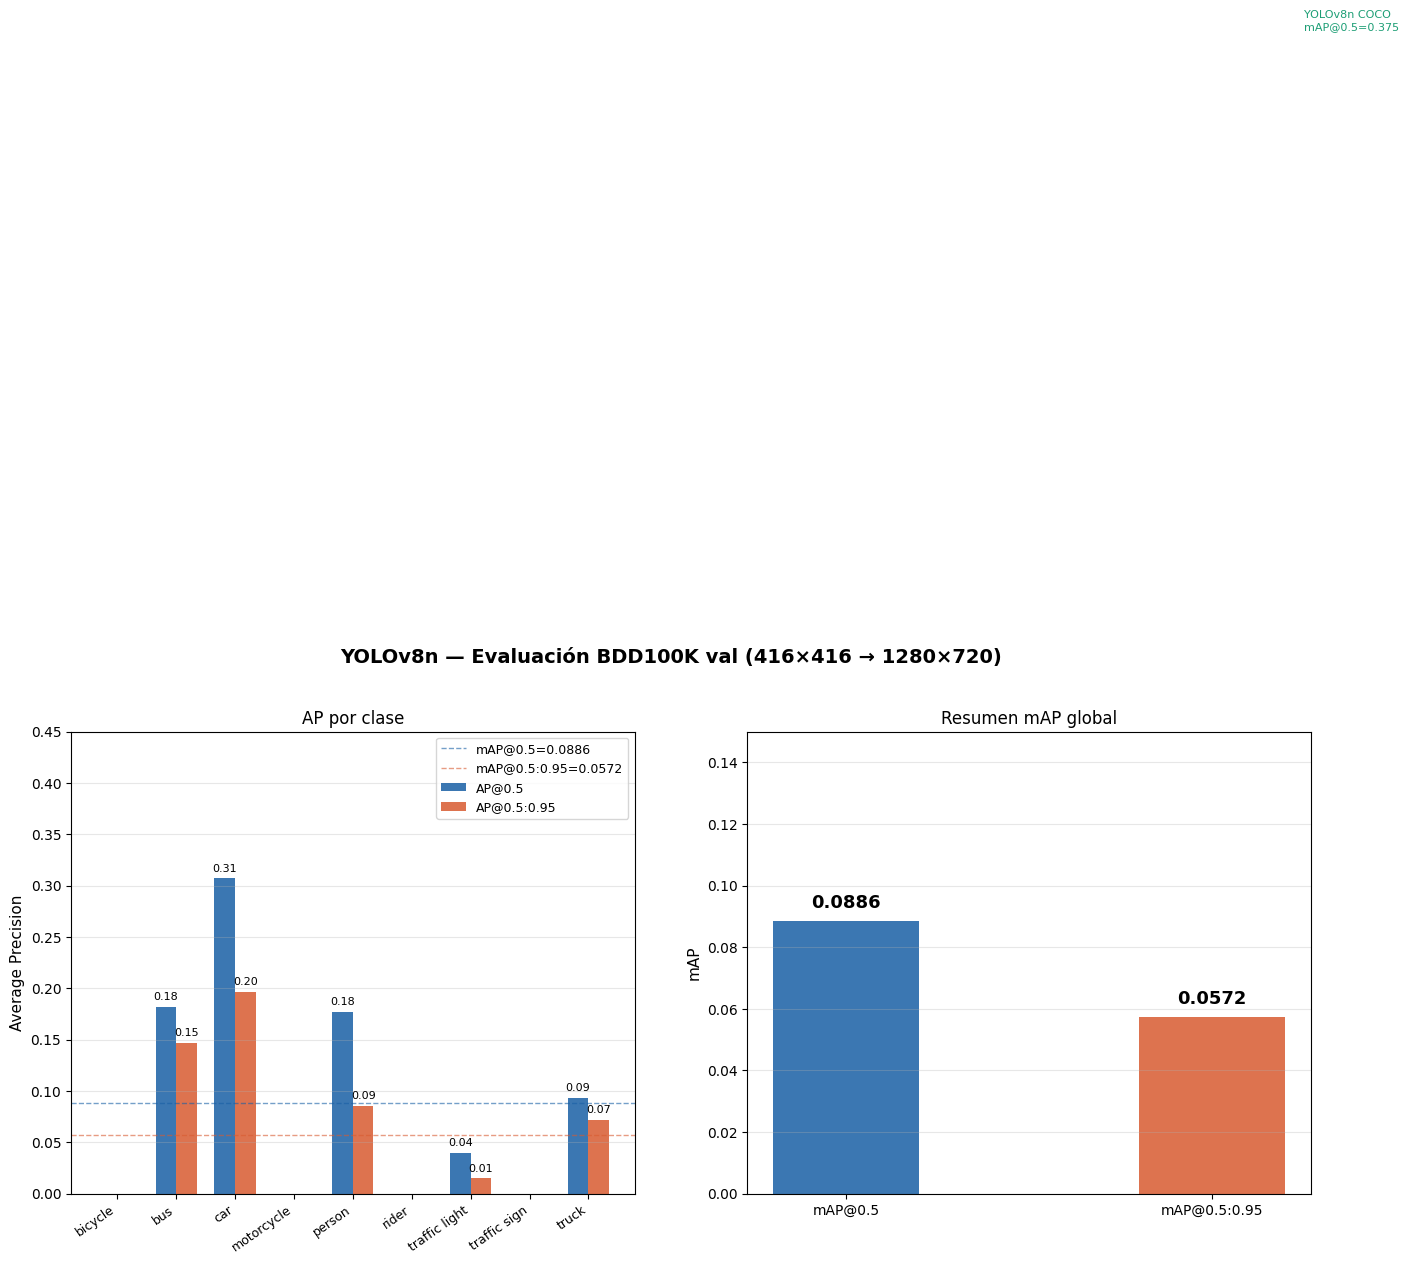

Gráfica guardada en: /mnt/bigdata/pipeline_samsung/Equipo8-Grupo8-SIC-2025-/notebooks/data/spatial_outputs/yolo_evaluation.png

  Resumen YOLOv8n — BDD100K val
  mAP@0.5      : 0.0886
  mAP@0.5:0.95 : 0.0572
  Mejor clase  : car (AP@0.5=0.3070)
  Clases sin detección: bicycle, motorcycle, rider, traffic sign
  Causa: YOLOv8n preentrenado en COCO — clases BDD100K no coinciden


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ── Datos ──────────────────────────────────────────────────────────
clases    = sorted(CLASES_VALIDAS)
ap50      = [aps[c] for c in clases]
ap5095    = [aps_95[c] for c in clases]

x     = np.arange(len(clases))
ancho = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("YOLOv8n — Evaluación BDD100K val (416×416 → 1280×720)",
             fontsize=14, fontweight="bold", y=1.02)

# ── Gráfica 1: AP por clase ────────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar(x - ancho/2, ap50,   ancho, label="AP@0.5",
                color="#185FA5", alpha=0.85)
bars2 = ax1.bar(x + ancho/2, ap5095, ancho, label="AP@0.5:0.95",
                color="#D85A30", alpha=0.85)

# Etiquetas encima de cada barra
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(clases, rotation=35, ha="right", fontsize=9)
ax1.set_ylabel("Average Precision", fontsize=11)
ax1.set_title("AP por clase", fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 0.45)
ax1.grid(True, alpha=0.3, axis="y")
ax1.axhline(map50, color="#185FA5", linestyle="--",
            linewidth=1, alpha=0.6, label=f"mAP@0.5={map50:.4f}")
ax1.axhline(map5095, color="#D85A30", linestyle="--",
            linewidth=1, alpha=0.6, label=f"mAP@0.5:0.95={map5095:.4f}")
ax1.legend(fontsize=9)

# ── Gráfica 2: mAP resumen ────────────────────────────────────────
ax2 = axes[1]
metricas = ["mAP@0.5", "mAP@0.5:0.95"]
valores  = [map50, map5095]
colores  = ["#185FA5", "#D85A30"]

bars = ax2.bar(metricas, valores, color=colores, alpha=0.85, width=0.4)
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=13, fontweight="bold")

ax2.set_ylabel("mAP", fontsize=11)
ax2.set_title("Resumen mAP global", fontsize=12)
ax2.set_ylim(0, 0.15)
ax2.grid(True, alpha=0.3, axis="y")

# Referencia YOLOv8n en COCO
ax2.axhline(0.375, color="#1D9E75", linestyle="--",
            linewidth=1.5, alpha=0.7)
ax2.text(1.25, 0.378, "YOLOv8n COCO\nmAP@0.5=0.375",
         fontsize=8, color="#1D9E75")

plt.tight_layout()
plt.savefig(str(OUT_BASE / "yolo_evaluation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfica guardada en: {OUT_BASE}/yolo_evaluation.png")

# ── Resumen estadístico ────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Resumen YOLOv8n — BDD100K val")
print(f"{'='*50}")
print(f"  mAP@0.5      : {map50:.4f}")
print(f"  mAP@0.5:0.95 : {map5095:.4f}")
print(f"  Mejor clase  : car (AP@0.5={aps['car']:.4f})")
print(f"  Clases sin detección: bicycle, motorcycle, rider, traffic sign")
print(f"  Causa: YOLOv8n preentrenado en COCO — clases BDD100K no coinciden")
print(f"{'='*50}")